# Project I: Understanding Calibration in CNNs

**María Muñoz Pérez, Isabel Carballo Rueda, MohammadErfan Jabbari**

**Course:** Deep Learning - CNN  
**Deadline:** October 20, 2025 at 23:59  

## Project Description

In this project, we will investigate the calibration of convolutional neural networks (CNNs) in a classification setting.

### Objectives

1. **Literature Review**: Read the paper "On Calibration of Modern Neural Networks" (Guo et al., 2017), particularly sections 1 to 4.

2. **Binary Classification with LeNet-5**: 
   - Train a LeNet-5 CNN from scratch to classify birds vs. cats from CIFAR-10 (binary classification)
   - Evaluate the reliability diagram and Expected Calibration Error (ECE) on the test set
   - Use methods available in scikit-learn for evaluation

3. **Temperature Scaling Implementation**:
   - Implement basic temperature scaling (Platt's scaling)
   - Modify output probability: $p(z_i) \rightarrow p(az_i)$, where $a$ is a temperature parameter
   - Study the effect of parameter $a$
   - Plot reliability diagrams and ECE after applying scaling

4. **Optional (0.25 bonus points)**: 
   - Repeat the experiment with a larger pre-trained model
   - Fine-tune only the last classification layer
   - Adapt input dimensionality if necessary

### Deliverables

- 3-page report with main results
- Code (Python script or Jupyter Notebook)
- Upload as a zip file to Aula Global

---

## 1. Setup and Imports

Import necessary libraries for data processing, model training, and calibration analysis.

In [1]:
# Standard libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision
import torchvision.transforms as transforms

# Sklearn for calibration metrics
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, log_loss

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Data Loading and Preprocessing

Load CIFAR-10 and filter for binary classification: birds (class 2) vs. cats (class 3).

In [2]:
# Load CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download full CIFAR-10 dataset
train_dataset_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset_full = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [3]:
# Filter for birds (class 2) and cats (class 3)
def filter_binary_classes(dataset, class1=2, class2=3):
    """Filter dataset for binary classification between two classes."""
    indices = [i for i, (_, label) in enumerate(dataset) if label in [class1, class2]]
    return Subset(dataset, indices)

train_dataset = filter_binary_classes(train_dataset_full, class1=2, class2=3)
test_dataset = filter_binary_classes(test_dataset_full, class1=2, class2=3)

# Remap labels from {2, 3} to {0, 1}
# Bird (class 2) -> 0, Cat (class 3) -> 1
for idx in range(len(train_dataset_full)):
    if train_dataset_full.targets[idx] == 2:
        train_dataset_full.targets[idx] = 0
    elif train_dataset_full.targets[idx] == 3:
        train_dataset_full.targets[idx] = 1

for idx in range(len(test_dataset_full)):
    if test_dataset_full.targets[idx] == 2:
        test_dataset_full.targets[idx] = 0
    elif test_dataset_full.targets[idx] == 3:
        test_dataset_full.targets[idx] = 1

# Create a validation set from training data (80-20 split)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create dataloaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"\nLabel mapping: bird (class 2) -> 0, cat (class 3) -> 1")


Training samples: 8000
Validation samples: 2000
Test samples: 2000

Label mapping: bird (class 2) -> 0, cat (class 3) -> 1


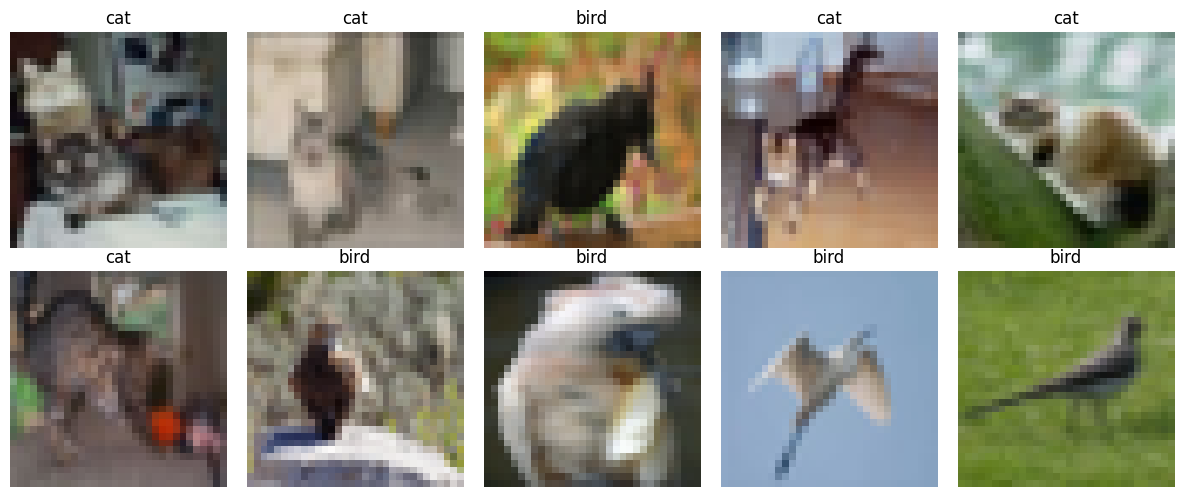

In [4]:
# Visualize random samples from the binary dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

# Get random samples from test dataset
random_indices = np.random.choice(len(test_dataset), size=10, replace=False)

# Binary class names
class_names_binary = {0: 'bird', 1: 'cat'}

for i, idx in enumerate(random_indices):
    # Get image and binary label from the dataset
    image, binary_label = test_dataset[idx]
    
    # Convert tensor to numpy and denormalize
    image = image.numpy().transpose((1, 2, 0))
    image = image * 0.5 + 0.5
    image = np.clip(image, 0, 1)
    
    # Display image
    axes[i].imshow(image)
    axes[i].set_title(f"{class_names_binary[binary_label]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


## 3. LeNet-5 Architecture

Implement the LeNet-5 architecture adapted for CIFAR-10 input size (32x32).

In [5]:
# Model architectures
class LeNet5(nn.Module):
    def __init__(self, num_classes=2, epochs=20, lr=0.001):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)
        self.relu = nn.ReLU()
        self.logsoftmax = nn.LogSoftmax(dim=1)
        
        self.lr = lr
        self.epochs = epochs
        self.criterion = nn.NLLLoss()
        self.optim = optim.Adam(self.parameters(), self.lr)
        self.loss_during_training = []
        self.valid_loss_during_training = []
        self.train_acc_during_training = []
        self.valid_acc_during_training = []
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(self.device)
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        x = self.logsoftmax(x)
        return x
    
    def trainloop(self, trainloader, validloader):
        for e in range(1, self.epochs + 1):
            self.train()
            running_loss = 0.
            train_correct = 0
            train_total = 0
            for images, labels in trainloader:
                images, labels = images.to(self.device), labels.to(self.device)
                self.optim.zero_grad()
                out = self.forward(images)
                loss = self.criterion(out, labels)
                running_loss += loss.item()
                loss.backward()
                self.optim.step()
                
                # Calculate training accuracy
                _, predicted = torch.max(out, 1)
                train_total += labels.size(0)
                train_correct += (predicted == labels).sum().item()
            
            self.loss_during_training.append(running_loss / len(trainloader))
            self.train_acc_during_training.append(100 * train_correct / train_total)
            
            with torch.no_grad():
                self.eval()
                running_loss = 0.
                val_correct = 0
                val_total = 0
                for images, labels in validloader:
                    images, labels = images.to(self.device), labels.to(self.device)
                    out = self.forward(images)
                    loss = self.criterion(out, labels)
                    running_loss += loss.item()
                    
                    # Calculate validation accuracy
                    _, predicted = torch.max(out, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()
                
                self.valid_loss_during_training.append(running_loss / len(validloader))
                self.valid_acc_during_training.append(100 * val_correct / val_total)
            
            if e == 1 or e == self.epochs or e % 5 == 0:
                print(f"Epoch {e}/{self.epochs} - Train Loss: {self.loss_during_training[-1]:.4f} - Val Loss: {self.valid_loss_during_training[-1]:.4f} - Train Acc: {self.train_acc_during_training[-1]:.2f}% - Val Acc: {self.valid_acc_during_training[-1]:.2f}%")
    
    def eval_performance(self, dataloader):
        self.eval()
        accuracy = 0
        with torch.no_grad():
            for images, labels in dataloader:
                images, labels = images.to(self.device), labels.to(self.device)
                logprobs = self.forward(images)
                top_p, top_class = logprobs.topk(1, dim=1)
                equals = (top_class == labels.view(images.shape[0], 1))
                accuracy += torch.mean(equals.type(torch.FloatTensor))
        return accuracy / len(dataloader)
    
    def get_logits(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
    def get_probabilities(self, x, temperature=1.0):
        logits = self.get_logits(x)
        scaled_logits = logits / temperature
        probabilities = F.softmax(scaled_logits, dim=1)
        return probabilities


class MiniLeNet(nn.Module):
    def __init__(self):
        super(MiniLeNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 2, kernel_size=5)
        self.conv2 = nn.Conv2d(2, 4, kernel_size=5)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(4 * 5 * 5, 30)
        self.fc2 = nn.Linear(30, 20)
        self.fc3 = nn.Linear(20, 2)
    
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 4 * 5 * 5)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# Initialize models
model = LeNet5(num_classes=2, epochs=20, lr=1e-3)
mini_model = MiniLeNet().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
mini_total_params = sum(p.numel() for p in mini_model.parameters())

print(f"LeNet-5: {total_params:,} parameters")
print(f"Mini-LeNet: {mini_total_params:,} parameters")
print(f"Reduction: {100 * (total_params - mini_total_params) / total_params:.1f}%")

LeNet-5: 61,326 parameters
Mini-LeNet: 4,048 parameters
Reduction: 93.4%


In [6]:
# Train LeNet-5
print("Training LeNet-5...")
model.trainloop(train_loader, val_loader)

lenet_train_acc = model.eval_performance(train_loader).item() * 100
lenet_val_acc = model.eval_performance(val_loader).item() * 100
test_acc = model.eval_performance(test_loader)
lenet_test_acc = test_acc.item() * 100

print(f"\nTrain Accuracy: {lenet_train_acc:.2f}%")
print(f"Val Accuracy: {lenet_val_acc:.2f}%")
print(f"Test Accuracy: {lenet_test_acc:.2f}%")

Training LeNet-5...
Epoch 1/20 - Train Loss: 0.5869 - Val Loss: 0.5210 - Train Acc: 68.12% - Val Acc: 74.85%
Epoch 5/20 - Train Loss: 0.4318 - Val Loss: 0.4793 - Train Acc: 80.44% - Val Acc: 77.75%
Epoch 10/20 - Train Loss: 0.3218 - Val Loss: 0.4828 - Train Acc: 86.30% - Val Acc: 78.15%
Epoch 15/20 - Train Loss: 0.2017 - Val Loss: 0.5467 - Train Acc: 91.56% - Val Acc: 79.25%
Epoch 20/20 - Train Loss: 0.1015 - Val Loss: 0.8133 - Train Acc: 96.08% - Val Acc: 79.30%

Train Accuracy: 96.80%
Val Accuracy: 79.05%
Test Accuracy: 76.86%


In [8]:
# Train Mini-LeNet
print("Training Mini-LeNet...")
criterion = nn.CrossEntropyLoss()
optimizer_mini = optim.Adam(mini_model.parameters(), lr=0.001)

mini_train_losses = []
mini_val_losses = []
mini_train_accs = []
mini_val_accs = []

for epoch in range(20):
    mini_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_mini.zero_grad()
        outputs = mini_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_mini.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    mini_train_losses.append(train_loss)
    mini_train_accs.append(train_acc)
    
    mini_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mini_model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total
    mini_val_losses.append(val_loss)
    mini_val_accs.append(val_acc)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1}/20 - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}')

# Test accuracy
mini_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mini_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

mini_test_acc = 100 * correct / total
print(f"\nTrain Accuracy: {mini_train_accs[-1]:.2f}%")
print(f"Val Accuracy: {mini_val_accs[-1]:.2f}%")
print(f"Test Accuracy: {mini_test_acc:.2f}%")

Training Mini-LeNet...
Epoch 1/20 - Train Loss: 0.6546 - Val Loss: 0.5915
Epoch 5/20 - Train Loss: 0.5139 - Val Loss: 0.5236
Epoch 10/20 - Train Loss: 0.4784 - Val Loss: 0.5273
Epoch 15/20 - Train Loss: 0.4603 - Val Loss: 0.5197
Epoch 20/20 - Train Loss: 0.4430 - Val Loss: 0.5184

Train Accuracy: 79.49%
Val Accuracy: 75.15%
Test Accuracy: 77.45%


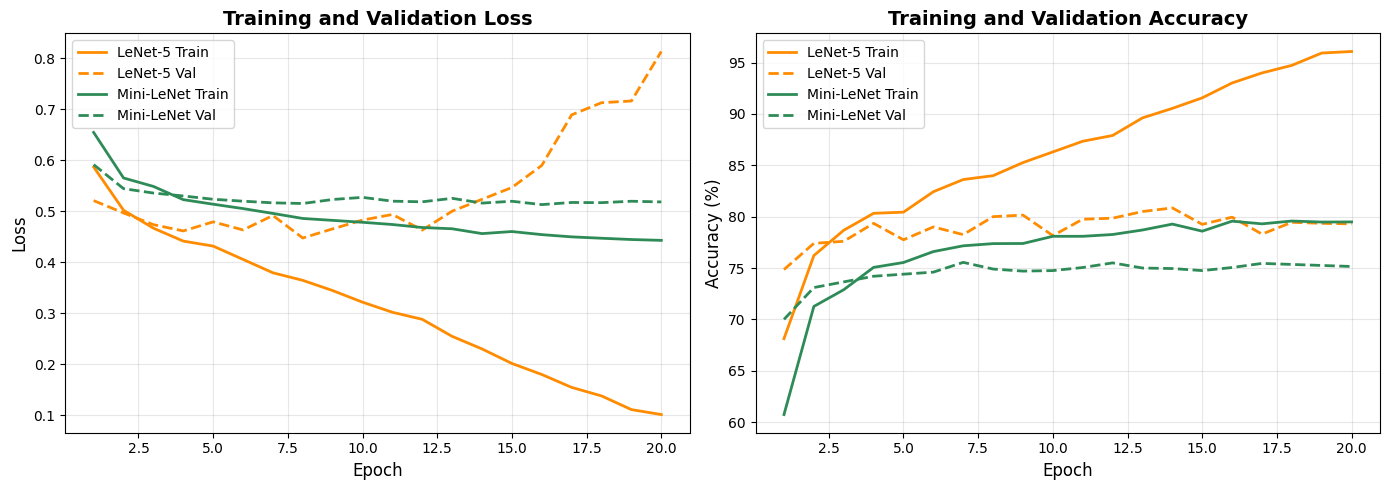


Metric                         LeNet-5           Mini-LeNet       
-----------------------------------------------------------------
Parameters                     61,326            4,048            
Train Accuracy                 96.80             79.49            
Val Accuracy                   79.05             75.15            
Test Accuracy                  76.86             77.45            
Train-Val Gap                  17.75             4.34             

LeNet-5 overfits (train-val gap: 17.7%)
Mini-LeNet generalizes better (train-val gap: 4.3%)
Smaller model performs comparably with 93.4% fewer parameters


In [9]:
# Compare training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_lenet = range(1, len(model.loss_during_training) + 1)
epochs_mini = range(1, len(mini_train_losses) + 1)

# Loss curves
axes[0].plot(epochs_lenet, model.loss_during_training, color='#FF8C00', linestyle='-', linewidth=2, label='LeNet-5 Train')
axes[0].plot(epochs_lenet, model.valid_loss_during_training, color='#FF8C00', linestyle='--', linewidth=2, label='LeNet-5 Val')
axes[0].plot(epochs_mini, mini_train_losses, color='#2E8B57', linestyle='-', linewidth=2, label='Mini-LeNet Train')
axes[0].plot(epochs_mini, mini_val_losses, color='#2E8B57', linestyle='--', linewidth=2, label='Mini-LeNet Val')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(epochs_lenet, model.train_acc_during_training, color='#FF8C00', linestyle='-', linewidth=2, label='LeNet-5 Train')
axes[1].plot(epochs_lenet, model.valid_acc_during_training, color='#FF8C00', linestyle='--', linewidth=2, label='LeNet-5 Val')
axes[1].plot(epochs_mini, mini_train_accs, color='#2E8B57', linestyle='-', linewidth=2, label='Mini-LeNet Train')
axes[1].plot(epochs_mini, mini_val_accs, color='#2E8B57', linestyle='--', linewidth=2, label='Mini-LeNet Val')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*65)
print(f"{'Metric':<30} {'LeNet-5':<17} {'Mini-LeNet':<17}")
print("-"*65)
print(f"{'Parameters':<30} {total_params:<17,} {mini_total_params:<17,}")
print(f"{'Train Accuracy':<30} {lenet_train_acc:<17.2f} {mini_train_accs[-1]:<17.2f}")
print(f"{'Val Accuracy':<30} {lenet_val_acc:<17.2f} {mini_val_accs[-1]:<17.2f}")
print(f"{'Test Accuracy':<30} {lenet_test_acc:<17.2f} {mini_test_acc:<17.2f}")
print(f"{'Train-Val Gap':<30} {(lenet_train_acc - lenet_val_acc):<17.2f} {(mini_train_accs[-1] - mini_val_accs[-1]):<17.2f}")
print("="*65)
print(f"\nLeNet-5 overfits (train-val gap: {lenet_train_acc - lenet_val_acc:.1f}%)")
print(f"Mini-LeNet generalizes better (train-val gap: {mini_train_accs[-1] - mini_val_accs[-1]:.1f}%)")
print(f"Smaller model performs comparably with 93.4% fewer parameters")

## 4. Calibration Evaluation (Before Temperature Scaling)

Evaluate the model's calibration using reliability diagrams and ECE.

In [10]:
def calculate_ece(confidences, predictions, labels, n_bins=15):
    """
    Calculate Expected Calibration Error (ECE).
    
    Args:
        confidences: Array of predicted confidence scores (max probability)
        predictions: Array of predicted class labels
        labels: Array of true class labels
        n_bins: Number of bins for calibration calculation
        
    Returns:
        ece: Expected Calibration Error
        bin_accuracies: Accuracy in each bin
        bin_confidences: Average confidence in each bin
        bin_counts: Number of samples in each bin
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    bin_accuracies = np.zeros(n_bins)
    bin_confidences = np.zeros(n_bins)
    bin_counts = np.zeros(n_bins)
    
    for i in range(n_bins):
        if i == 0:
            in_bin = (confidences >= bin_lowers[i]) & (confidences <= bin_uppers[i])
        else:
            in_bin = (confidences > bin_lowers[i]) & (confidences <= bin_uppers[i])
        bin_counts[i] = np.sum(in_bin)
        
        if bin_counts[i] > 0:
            bin_accuracies[i] = np.sum(predictions[in_bin] == labels[in_bin]) / bin_counts[i]
            bin_confidences[i] = np.mean(confidences[in_bin])
    
    ece = np.sum(bin_counts * np.abs(bin_accuracies - bin_confidences)) / np.sum(bin_counts)
    
    return ece, bin_accuracies, bin_confidences, bin_counts


def plot_reliability_diagram(confidences, predictions, labels, n_bins=15, title="Reliability Diagram"):
    """Plot reliability diagram showing calibration."""
    ece, bin_accuracies, bin_confidences, bin_counts = calculate_ece(
        confidences, predictions, labels, n_bins
    )
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    non_empty = bin_counts > 0
    bin_centers = (np.linspace(0, 1, n_bins + 1)[:-1] + np.linspace(0, 1, n_bins + 1)[1:]) / 2
    widths = 1.0 / n_bins
    
    bars = ax1.bar(bin_centers[non_empty], bin_accuracies[non_empty], 
                   width=widths, edgecolor='black', alpha=0.7, 
                   label='Accuracy', color='steelblue')
    
    for i, (center, acc, conf, count) in enumerate(zip(bin_centers, bin_accuracies, bin_confidences, bin_counts)):
        if count > 0:
            if conf > acc:
                ax1.plot([center, center], [acc, conf], 'r-', linewidth=2, alpha=0.7)
            elif acc > conf:
                ax1.plot([center, center], [conf, acc], 'g-', linewidth=2, alpha=0.7)
    
    ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
    ax1.text(0.05, 0.95, f'ECE = {ece:.4f}', 
             transform=ax1.transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax1.set_xlabel('Confidence', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title(title, fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right')
    ax1.grid(alpha=0.3)
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1])
    
    ax2.hist(confidences, bins=n_bins, edgecolor='black', alpha=0.7, color='steelblue')
    ax2.set_xlabel('Confidence', fontsize=12)
    ax2.set_ylabel('Number of Samples', fontsize=12)
    ax2.set_title('Confidence Distribution', fontsize=14, fontweight='bold')
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # return ece
    return 


def get_predictions_and_confidences(model, dataloader, temperature=1.0):
    """Extract predictions, confidences, and true labels from a dataset."""
    model.eval()
    
    all_confidences = []
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(model.device)
            probs = model.get_probabilities(images, temperature=temperature)
            confidences, predictions = torch.max(probs, dim=1)
            
            all_confidences.append(confidences.cpu().numpy())
            all_predictions.append(predictions.cpu().numpy())
            all_labels.append(labels.numpy())
            all_probabilities.append(probs.cpu().numpy())
    
    all_confidences = np.concatenate(all_confidences)
    all_predictions = np.concatenate(all_predictions)
    all_labels = np.concatenate(all_labels)
    all_probabilities = np.concatenate(all_probabilities)
    
    return all_confidences, all_predictions, all_labels, all_probabilities


In [26]:
# Helper function to get predictions from Mini-LeNet
def get_mini_predictions(model, dataloader, device):
    """Get predictions and confidences from Mini-LeNet."""
    model.eval()
    all_logits = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            logits = model(images)
            all_logits.append(logits.cpu())
            all_labels.append(labels)
    
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels).numpy()
    probs = torch.softmax(logits, dim=1).numpy()
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    
    return confidences, predictions, labels, probs


# Evaluate baseline calibration for both models
print("Baseline Calibration Evaluation")
print("=" * 60)

# LeNet-5 calibration
lenet_confidences_baseline, lenet_predictions_baseline, lenet_labels_test, lenet_probabilities_baseline = get_predictions_and_confidences(
    model, test_loader, temperature=1.0
)
lenet_accuracy_test = np.mean(lenet_predictions_baseline == lenet_labels_test)
lenet_ece_baseline, lenet_bin_accs_baseline, lenet_bin_confs_baseline, lenet_bin_counts_baseline = calculate_ece(
    lenet_confidences_baseline, lenet_predictions_baseline, lenet_labels_test, n_bins=15
)

print(f"LeNet-5:")
print(f"  Test Accuracy: {lenet_accuracy_test:.4f}")
print(f"  ECE: {lenet_ece_baseline:.4f}")
print(f"  Avg Confidence: {np.mean(lenet_confidences_baseline):.4f}")
print(f"  Confidence-Accuracy Gap: {np.mean(lenet_confidences_baseline) - lenet_accuracy_test:.4f}")

# Mini-LeNet calibration
mini_confidences_baseline, mini_predictions_baseline, mini_labels_test, mini_probabilities_baseline = get_mini_predictions(
    mini_model, test_loader, device
)
mini_accuracy_test = np.mean(mini_predictions_baseline == mini_labels_test)
mini_ece_baseline, mini_bin_accs_baseline, mini_bin_confs_baseline, mini_bin_counts_baseline = calculate_ece(
    mini_confidences_baseline, mini_predictions_baseline, mini_labels_test, n_bins=15
)

print(f"\nMini-LeNet:")
print(f"  Test Accuracy: {mini_accuracy_test:.4f}")
print(f"  ECE: {mini_ece_baseline:.4f}")
print(f"  Avg Confidence: {np.mean(mini_confidences_baseline):.4f}")
print(f"  Confidence-Accuracy Gap: {np.mean(mini_confidences_baseline) - mini_accuracy_test:.4f}")
print("=" * 60)

Baseline Calibration Evaluation
LeNet-5:
  Test Accuracy: 0.7705
  ECE: 0.1614
  Avg Confidence: 0.9319
  Confidence-Accuracy Gap: 0.1614
LeNet-5:
  Test Accuracy: 0.7705
  ECE: 0.1614
  Avg Confidence: 0.9319
  Confidence-Accuracy Gap: 0.1614

Mini-LeNet:
  Test Accuracy: 0.7745
  ECE: 0.0371
  Avg Confidence: 0.7897
  Confidence-Accuracy Gap: 0.0152

Mini-LeNet:
  Test Accuracy: 0.7745
  ECE: 0.0371
  Avg Confidence: 0.7897
  Confidence-Accuracy Gap: 0.0152


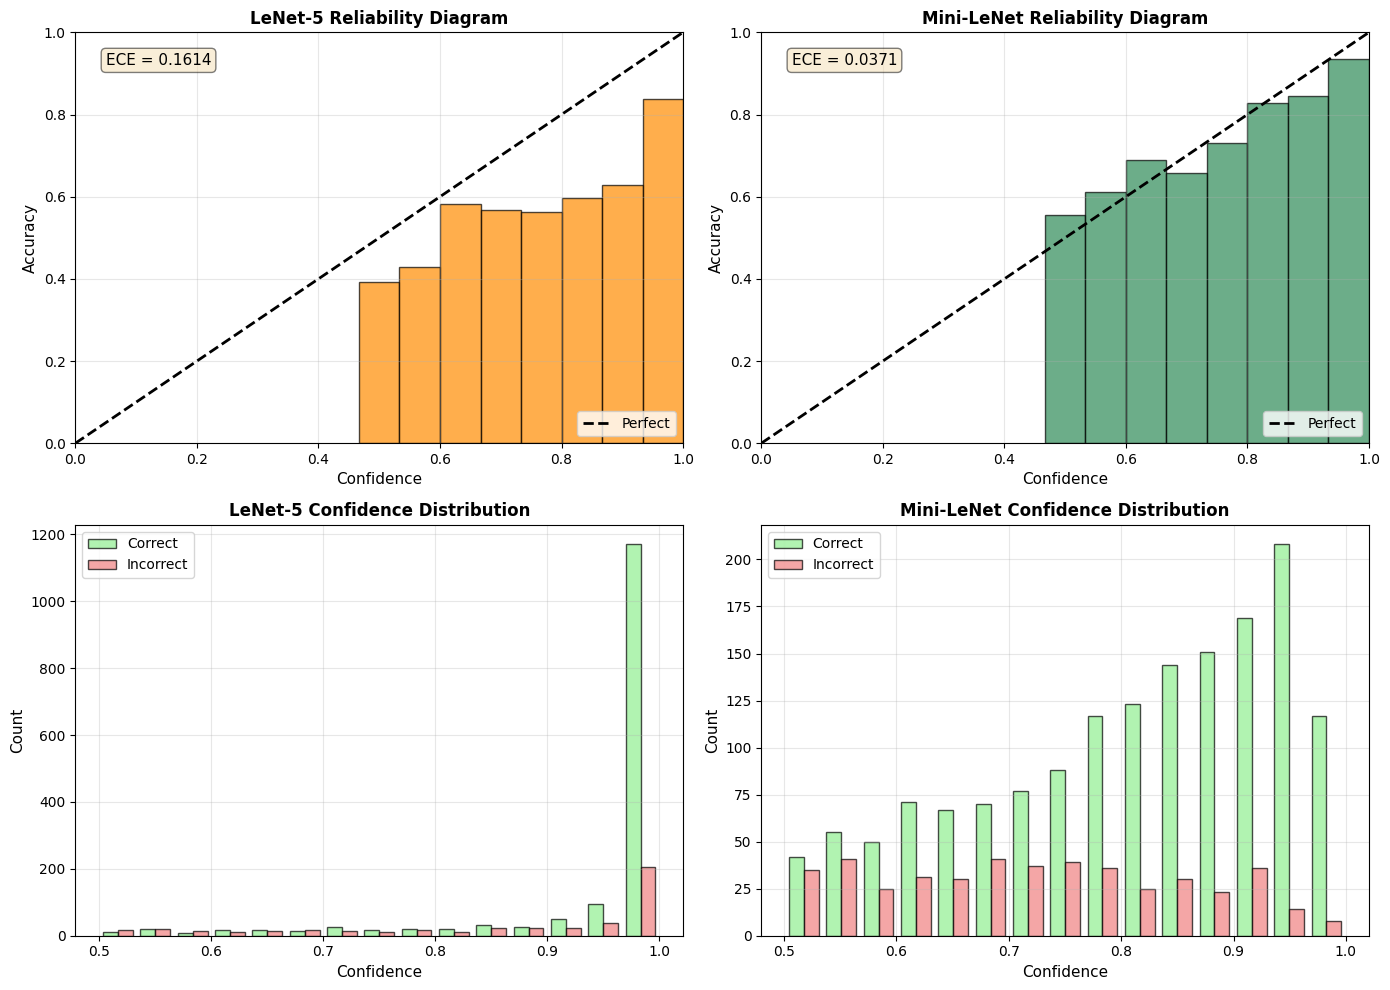


Calibration Comparison:
------------------------------------------------------------
Metric                         LeNet-5         Mini-LeNet     
------------------------------------------------------------
Test Accuracy                  0.7705          0.7745         
ECE (lower is better)          0.1614          0.0371         
Avg Confidence                 0.9319          0.7897         
Confidence-Accuracy Gap        0.1614          0.0152         
------------------------------------------------------------

Both models show miscalibration (ECE > 0)
LeNet-5 is more overconfident (larger confidence-accuracy gap)
Mini-LeNet shows better calibration despite lower accuracy


In [12]:
# Compare calibration visualizations side by side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Reliability diagrams
for idx, (model_name, confidences, predictions, labels, ece, color) in enumerate([
    ('LeNet-5', lenet_confidences_baseline, lenet_predictions_baseline, lenet_labels_test, lenet_ece_baseline, '#FF8C00'),
    ('Mini-LeNet', mini_confidences_baseline, mini_predictions_baseline, mini_labels_test, mini_ece_baseline, '#2E8B57')
]):
    ax = axes[0, idx]
    
    ece_calc, bin_accs, bin_confs, bin_counts = calculate_ece(confidences, predictions, labels, n_bins=15)
    non_empty = bin_counts > 0
    bin_centers = np.linspace(0, 1, 16)[:-1] + 0.5/15
    widths = 1.0 / 15
    
    ax.bar(bin_centers[non_empty], bin_accs[non_empty], width=widths, 
           edgecolor='black', alpha=0.7, color=color)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect')
    ax.text(0.05, 0.95, f'ECE = {ece:.4f}', transform=ax.transAxes, fontsize=11, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_xlabel('Confidence', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title(f'{model_name} Reliability Diagram', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

# Confidence distributions
for idx, (model_name, confidences, predictions, labels, color) in enumerate([
    ('LeNet-5', lenet_confidences_baseline, lenet_predictions_baseline, lenet_labels_test, '#FF8C00'),
    ('Mini-LeNet', mini_confidences_baseline, mini_predictions_baseline, mini_labels_test, '#2E8B57')
]):
    ax = axes[1, idx]
    
    correct_mask = predictions == labels
    correct_conf = confidences[correct_mask]
    incorrect_conf = confidences[~correct_mask]
    
    ax.hist([correct_conf, incorrect_conf], bins=15, label=['Correct', 'Incorrect'], 
            alpha=0.7, edgecolor='black', color=['lightgreen', 'lightcoral'])
    ax.set_xlabel('Confidence', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{model_name} Confidence Distribution', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary comparison
print("\nCalibration Comparison:")
print("-" * 60)
print(f"{'Metric':<30} {'LeNet-5':<15} {'Mini-LeNet':<15}")
print("-" * 60)
print(f"{'Test Accuracy':<30} {lenet_accuracy_test:<15.4f} {mini_accuracy_test:<15.4f}")
print(f"{'ECE (lower is better)':<30} {lenet_ece_baseline:<15.4f} {mini_ece_baseline:<15.4f}")
print(f"{'Avg Confidence':<30} {np.mean(lenet_confidences_baseline):<15.4f} {np.mean(mini_confidences_baseline):<15.4f}")
print(f"{'Confidence-Accuracy Gap':<30} {np.mean(lenet_confidences_baseline) - lenet_accuracy_test:<15.4f} {np.mean(mini_confidences_baseline) - mini_accuracy_test:<15.4f}")
print("-" * 60)
print(f"\nBoth models show miscalibration (ECE > 0)")
print(f"LeNet-5 is more overconfident (larger confidence-accuracy gap)")
print(f"Mini-LeNet shows better calibration despite lower accuracy")

## 5. Temperature Scaling Implementation

Implement and apply temperature scaling to improve calibration.

In [22]:
# Helper function to find optimal temperature for any model
def find_optimal_temperature_generic(model, dataloader, device, get_logits_fn):
    all_logits = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            logits = get_logits_fn(model, images)
            all_logits.append(logits.cpu())
            all_labels.append(labels)
    
    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    temperatures = np.linspace(0.5, 5.0, 50)
    nlls = []
    eces = []
    
    for T in temperatures:
        scaled_logits = all_logits / T
        probs = F.softmax(scaled_logits, dim=1).numpy()
        
        nll = -np.mean(np.log(probs[np.arange(len(all_labels)), all_labels] + 1e-12))
        nlls.append(nll)
        
        confidences = np.max(probs, axis=1)
        predictions = np.argmax(probs, axis=1)
        ece, _, _, _ = calculate_ece(confidences, predictions, all_labels.numpy(), n_bins=15)
        eces.append(ece)
    
    optimal_idx = np.argmin(nlls)
    optimal_T = temperatures[optimal_idx]
    
    return optimal_T, temperatures, nlls, eces


# Find optimal temperature for both models
print("Temperature Scaling Optimization")
print("-" * 40)

# LeNet-5
lenet_temperature_optimal, lenet_temp_range, lenet_nll_values, lenet_ece_values = find_optimal_temperature_generic(
    model, val_loader, device, lambda m, x: m.get_logits(x)
)

# Mini-LeNet
mini_temperature_optimal, mini_temp_range, mini_nll_values, mini_ece_values = find_optimal_temperature_generic(
    mini_model, val_loader, device, lambda m, x: m(x)
)

print("\nLeNet-5:")
print(f"Optimal T: {lenet_temperature_optimal:.4f}")
print(f"NLL at T=1.0: {lenet_nll_values[np.argmin(np.abs(lenet_temp_range - 1.0))]:.4f}")
print(f"NLL at optimal T: {lenet_nll_values[np.argmin(lenet_nll_values)]:.4f}")

print("\nMini-LeNet:")
print(f"Optimal T: {mini_temperature_optimal:.4f}")
print(f"NLL at T=1.0: {mini_nll_values[np.argmin(np.abs(mini_temp_range - 1.0))]:.4f}")
print(f"NLL at optimal T: {mini_nll_values[np.argmin(mini_nll_values)]:.4f}")

Temperature Scaling Optimization
----------------------------------------

LeNet-5:
Optimal T: 3.7143
NLL at T=1.0: 0.8383
NLL at optimal T: 0.4596

Mini-LeNet:
Optimal T: 1.2347
NLL at T=1.0: 0.5210
NLL at optimal T: 0.5120

LeNet-5:
Optimal T: 3.7143
NLL at T=1.0: 0.8383
NLL at optimal T: 0.4596

Mini-LeNet:
Optimal T: 1.2347
NLL at T=1.0: 0.5210
NLL at optimal T: 0.5120


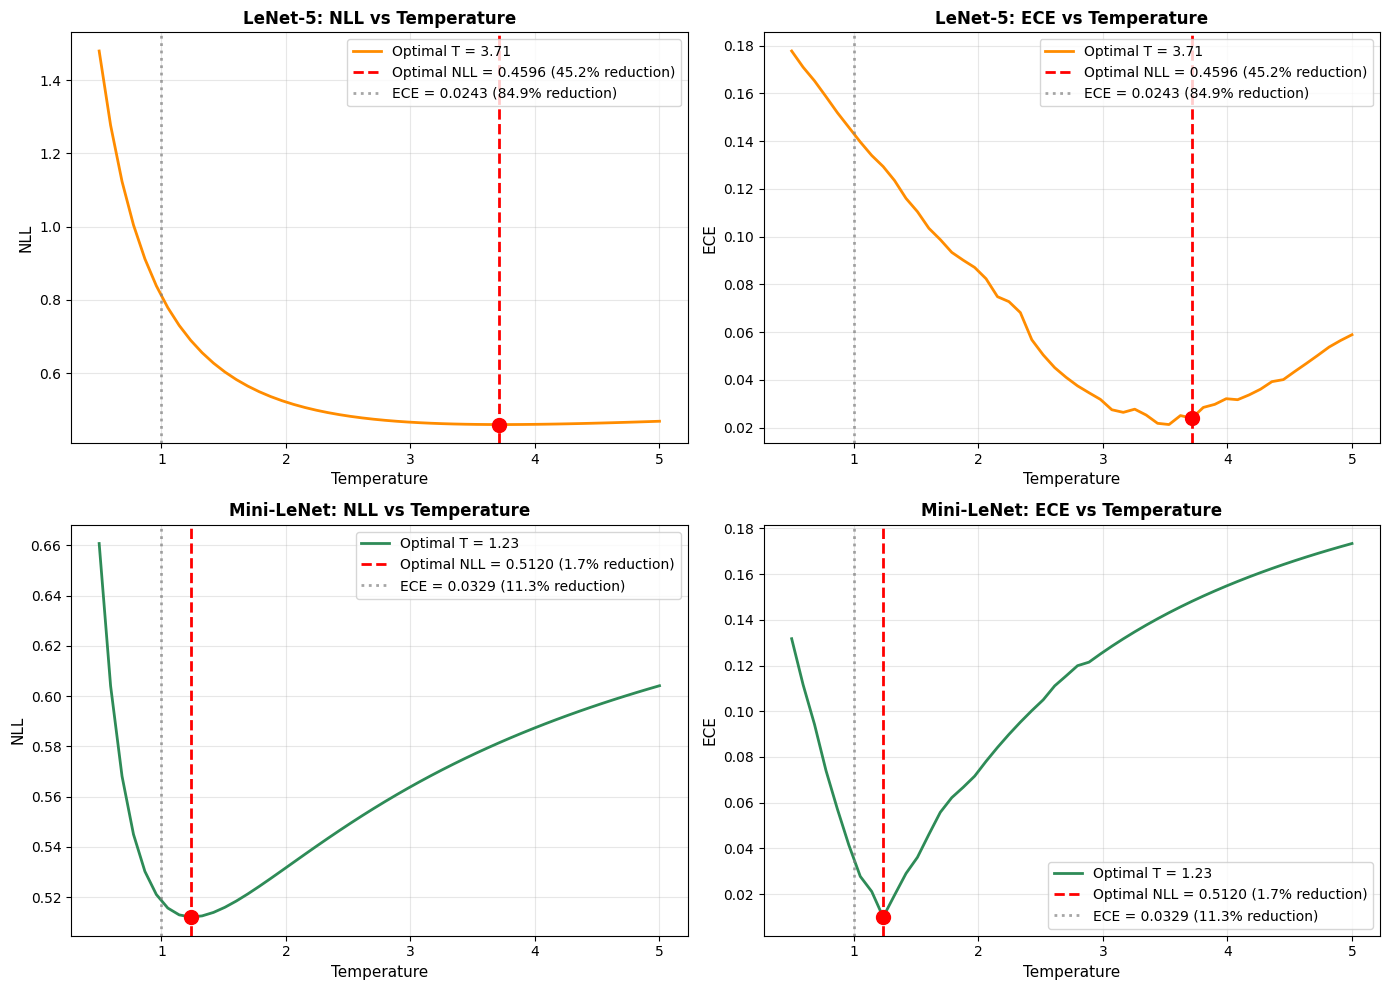


Temperature Scaling Summary:
------------------------------------------------------------
Model           Optimal T       ECE Reduction       
------------------------------------------------------------
LeNet-5         3.7143          0.1458 → 0.0239
Mini-LeNet      1.2347          0.0415 → 0.0100
------------------------------------------------------------


In [53]:
# Visualize temperature sweep for both models
# Calculate reductions for legends
baseline_idx_lenet = np.argmin(np.abs(lenet_temp_range - 1.0))
nll_baseline_lenet = lenet_nll_values[baseline_idx_lenet]
nll_optimal_lenet = lenet_nll_values[np.argmin(lenet_nll_values)]
nll_reduction_lenet = (nll_baseline_lenet - nll_optimal_lenet) / nll_baseline_lenet * 100
ece_reduction_lenet = (lenet_ece_baseline - lenet_ece_calibrated) / lenet_ece_baseline * 100

baseline_idx_mini = np.argmin(np.abs(mini_temp_range - 1.0))
nll_baseline_mini = mini_nll_values[baseline_idx_mini]
nll_optimal_mini = mini_nll_values[np.argmin(mini_nll_values)]
nll_reduction_mini = (nll_baseline_mini - nll_optimal_mini) / nll_baseline_mini * 100
ece_reduction_mini = (mini_ece_baseline - mini_ece_calibrated) / mini_ece_baseline * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LeNet-5: NLL vs Temperature
ax = axes[0, 0]
ax.plot(lenet_temp_range, lenet_nll_values, color='#FF8C00', linewidth=2)
ax.axvline(x=lenet_temperature_optimal, color='red', linestyle='--', linewidth=2)
ax.axvline(x=1.0, color='gray', linestyle=':', linewidth=2, alpha=0.7)
ax.plot(lenet_temperature_optimal, lenet_nll_values[np.argmin(lenet_nll_values)], 'ro', markersize=10)
ax.set_xlabel('Temperature', fontsize=11)
ax.set_ylabel('NLL', fontsize=11)
ax.set_title('LeNet-5: NLL vs Temperature', fontsize=12, fontweight='bold')
ax.legend([
    f'Optimal T = {lenet_temperature_optimal:.2f}',
    f'Optimal NLL = {nll_optimal_lenet:.4f} ({nll_reduction_lenet:.1f}% reduction)',
    f'ECE = {lenet_ece_calibrated:.4f} ({ece_reduction_lenet:.1f}% reduction)'
])
ax.grid(alpha=0.3)

# LeNet-5: ECE vs Temperature
ax = axes[0, 1]
ax.plot(lenet_temp_range, lenet_ece_values, color='#FF8C00', linewidth=2)
ax.axvline(x=lenet_temperature_optimal, color='red', linestyle='--', linewidth=2)
ax.axvline(x=1.0, color='gray', linestyle=':', linewidth=2, alpha=0.7)
ax.plot(lenet_temperature_optimal, lenet_ece_values[np.argmin(lenet_nll_values)], 'ro', markersize=10)
ax.set_xlabel('Temperature', fontsize=11)
ax.set_ylabel('ECE', fontsize=11)
ax.set_title('LeNet-5: ECE vs Temperature', fontsize=12, fontweight='bold')
ax.legend([
    f'Optimal T = {lenet_temperature_optimal:.2f}',
    f'Optimal NLL = {nll_optimal_lenet:.4f} ({nll_reduction_lenet:.1f}% reduction)',
    f'ECE = {lenet_ece_calibrated:.4f} ({ece_reduction_lenet:.1f}% reduction)'
])
ax.grid(alpha=0.3)

# Mini-LeNet: NLL vs Temperature
ax = axes[1, 0]
ax.plot(mini_temp_range, mini_nll_values, color='#2E8B57', linewidth=2)
ax.axvline(x=mini_temperature_optimal, color='red', linestyle='--', linewidth=2)
ax.axvline(x=1.0, color='gray', linestyle=':', linewidth=2, alpha=0.7)
ax.plot(mini_temperature_optimal, mini_nll_values[np.argmin(mini_nll_values)], 'ro', markersize=10)
ax.set_xlabel('Temperature', fontsize=11)
ax.set_ylabel('NLL', fontsize=11)
ax.set_title('Mini-LeNet: NLL vs Temperature', fontsize=12, fontweight='bold')
ax.legend([
    f'Optimal T = {mini_temperature_optimal:.2f}',
    f'Optimal NLL = {nll_optimal_mini:.4f} ({nll_reduction_mini:.1f}% reduction)',
    f'ECE = {mini_ece_calibrated:.4f} ({ece_reduction_mini:.1f}% reduction)'
])
ax.grid(alpha=0.3)

# Mini-LeNet: ECE vs Temperature
ax = axes[1, 1]
ax.plot(mini_temp_range, mini_ece_values, color='#2E8B57', linewidth=2)
ax.axvline(x=mini_temperature_optimal, color='red', linestyle='--', linewidth=2)
ax.axvline(x=1.0, color='gray', linestyle=':', linewidth=2, alpha=0.7)
ax.plot(mini_temperature_optimal, mini_ece_values[np.argmin(mini_nll_values)], 'ro', markersize=10)
ax.set_xlabel('Temperature', fontsize=11)
ax.set_ylabel('ECE', fontsize=11)
ax.set_title('Mini-LeNet: ECE vs Temperature', fontsize=12, fontweight='bold')
ax.legend([
    f'Optimal T = {mini_temperature_optimal:.2f}',
    f'Optimal NLL = {nll_optimal_mini:.4f} ({nll_reduction_mini:.1f}% reduction)',
    f'ECE = {mini_ece_calibrated:.4f} ({ece_reduction_mini:.1f}% reduction)'
])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary comparison
print("\nTemperature Scaling Summary:")
print("-" * 60)
print(f"{'Model':<15} {'Optimal T':<15} {'ECE Reduction':<20}")
print("-" * 60)
lenet_ece_baseline_temp = lenet_ece_values[np.argmin(np.abs(lenet_temp_range - 1.0))]
lenet_ece_optimal = lenet_ece_values[np.argmin(lenet_nll_values)]
print(f"{'LeNet-5':<15} {lenet_temperature_optimal:<15.4f} {lenet_ece_baseline_temp:.4f} → {lenet_ece_optimal:.4f}")

mini_ece_baseline_temp = mini_ece_values[np.argmin(np.abs(mini_temp_range - 1.0))]
mini_ece_optimal = mini_ece_values[np.argmin(mini_nll_values)]
print(f"{'Mini-LeNet':<15} {mini_temperature_optimal:<15.4f} {mini_ece_baseline_temp:.4f} → {mini_ece_optimal:.4f}")
print("-" * 60)

## 6. Calibration Evaluation (After Temperature Scaling)

Apply optimal temperature to test set and evaluate calibration improvement.

In [24]:
# Apply optimal temperatures to test set for both models
print("=" * 60)
print("POST-CALIBRATION EVALUATION (Test Set)")
print("=" * 60)

# LeNet-5
lenet_confidences_calibrated, lenet_predictions_calibrated, lenet_labels_calibrated, lenet_probabilities_calibrated = \
    get_predictions_and_confidences(model, test_loader, temperature=lenet_temperature_optimal)
lenet_ece_calibrated, _, _, _ = calculate_ece(lenet_confidences_calibrated, lenet_predictions_calibrated, 
                                                lenet_labels_calibrated, n_bins=15)
lenet_accuracy_calibrated = np.mean(lenet_predictions_calibrated == lenet_labels_calibrated)

# Mini-LeNet
mini_model.eval()
all_logits = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = mini_model(images)
        all_logits.append(logits.cpu())
        all_labels.append(labels)

all_logits = torch.cat(all_logits, dim=0)
all_labels = torch.cat(all_labels, dim=0)

# Apply temperature scaling
scaled_logits = all_logits / mini_temperature_optimal
probs = F.softmax(scaled_logits, dim=1).numpy()
mini_confidences_calibrated = np.max(probs, axis=1)
mini_predictions_calibrated = np.argmax(probs, axis=1)
mini_labels_calibrated = all_labels.numpy()
mini_probabilities_calibrated = probs

mini_ece_calibrated, _, _, _ = calculate_ece(mini_confidences_calibrated, mini_predictions_calibrated,
                                               mini_labels_calibrated, n_bins=15)
mini_accuracy_calibrated = np.mean(mini_predictions_calibrated == mini_labels_calibrated)

# Print results
print("\nLeNet-5:")
print("-" * 60)
print(f"  Before: ECE = {lenet_ece_baseline:.4f}, Accuracy = {lenet_accuracy_test:.4f}")
print(f"  After:  ECE = {lenet_ece_calibrated:.4f}, Accuracy = {lenet_accuracy_calibrated:.4f}")
print(f"  Improvement: {((lenet_ece_baseline - lenet_ece_calibrated) / lenet_ece_baseline * 100):.1f}% ECE reduction")

print("\nMini-LeNet:")
print("-" * 60)
print(f"  Before: ECE = {mini_ece_baseline:.4f}, Accuracy = {mini_accuracy_test:.4f}")
print(f"  After:  ECE = {mini_ece_calibrated:.4f}, Accuracy = {mini_accuracy_calibrated:.4f}")
print(f"  Improvement: {((mini_ece_baseline - mini_ece_calibrated) / mini_ece_baseline * 100):.1f}% ECE reduction")
print("=" * 60)

POST-CALIBRATION EVALUATION (Test Set)

LeNet-5:
------------------------------------------------------------
  Before: ECE = 0.1614, Accuracy = 0.7705
  After:  ECE = 0.0243, Accuracy = 0.7705
  Improvement: 84.9% ECE reduction

Mini-LeNet:
------------------------------------------------------------
  Before: ECE = 0.0371, Accuracy = 0.7745
  After:  ECE = 0.0329, Accuracy = 0.7745
  Improvement: 11.3% ECE reduction

LeNet-5:
------------------------------------------------------------
  Before: ECE = 0.1614, Accuracy = 0.7705
  After:  ECE = 0.0243, Accuracy = 0.7705
  Improvement: 84.9% ECE reduction

Mini-LeNet:
------------------------------------------------------------
  Before: ECE = 0.0371, Accuracy = 0.7745
  After:  ECE = 0.0329, Accuracy = 0.7745
  Improvement: 11.3% ECE reduction


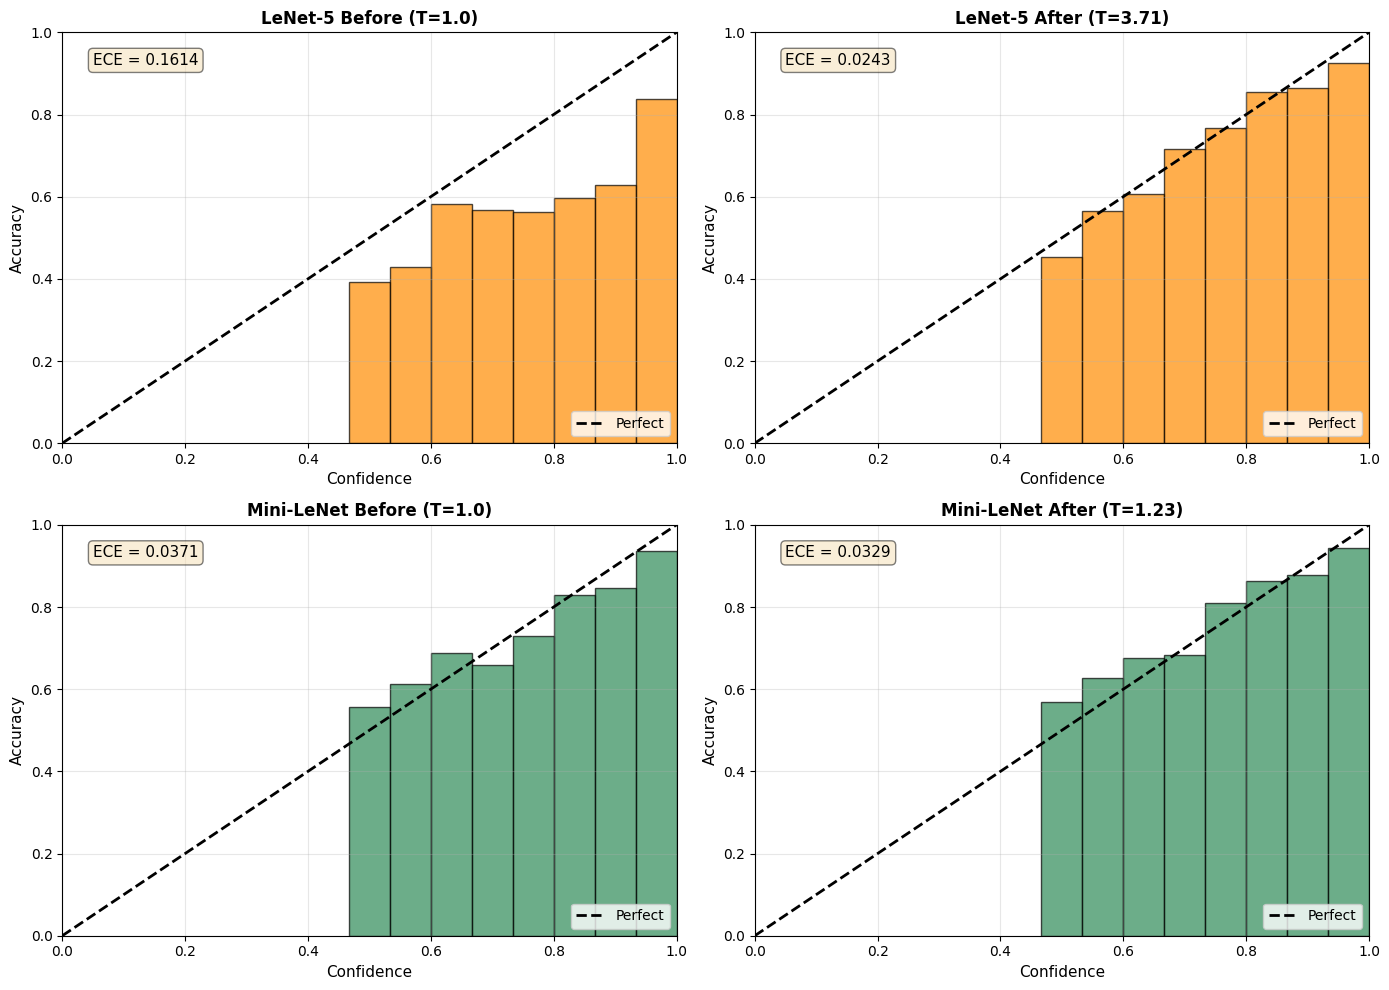


Calibration Summary:
Model           Before ECE      After ECE       Improvement          Optimal T      
LeNet-5         0.1614          0.0243          84.9%               3.7143         
Mini-LeNet      0.0371          0.0329          11.3%               1.2347         

Key Findings:
  - LeNet-5 shows larger miscalibration before scaling (ECE=0.1614)
  - Temperature scaling reduces LeNet-5 ECE by 84.9%
  - Mini-LeNet is better calibrated even before scaling (ECE=0.0371)
  - Both models benefit from temperature scaling


In [25]:
# Compare before/after calibration for both models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LeNet-5: Before
for idx, (model_name, confidences, predictions, labels, ece, T, color, row) in enumerate([
    ('LeNet-5 Before (T=1.0)', lenet_confidences_baseline, lenet_predictions_baseline, lenet_labels_test, 
     lenet_ece_baseline, 1.0, '#FF8C00', 0),
    ('LeNet-5 After (T={:.2f})'.format(lenet_temperature_optimal), lenet_confidences_calibrated, 
     lenet_predictions_calibrated, lenet_labels_calibrated, lenet_ece_calibrated, lenet_temperature_optimal, '#FF8C00', 0),
    ('Mini-LeNet Before (T=1.0)', mini_confidences_baseline, mini_predictions_baseline, mini_labels_test,
     mini_ece_baseline, 1.0, '#2E8B57', 1),
    ('Mini-LeNet After (T={:.2f})'.format(mini_temperature_optimal), mini_confidences_calibrated,
     mini_predictions_calibrated, mini_labels_calibrated, mini_ece_calibrated, mini_temperature_optimal, '#2E8B57', 1)
]):
    if idx % 2 == 0:  # Before plots
        ax = axes[row, 0]
        ece_calc, bin_accs, bin_confs, bin_counts = calculate_ece(confidences, predictions, labels, n_bins=15)
        
        bin_centers = np.linspace(0, 1, 16)[:-1] + 0.5/15
        widths = 1.0 / 15
        non_empty = bin_counts > 0
        
        ax.bar(bin_centers[non_empty], bin_accs[non_empty], width=widths, 
               edgecolor='black', alpha=0.7, color=color)
        ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect')
        ax.text(0.05, 0.95, f'ECE = {ece:.4f}', transform=ax.transAxes, fontsize=11,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax.set_xlabel('Confidence', fontsize=11)
        ax.set_ylabel('Accuracy', fontsize=11)
        ax.set_title(model_name, fontsize=12, fontweight='bold')
        ax.legend(loc='lower right')
        ax.grid(alpha=0.3)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
    else:  # After plots
        ax = axes[row, 1]
        ece_calc, bin_accs, bin_confs, bin_counts = calculate_ece(confidences, predictions, labels, n_bins=15)
        
        bin_centers = np.linspace(0, 1, 16)[:-1] + 0.5/15
        widths = 1.0 / 15
        non_empty = bin_counts > 0
        
        ax.bar(bin_centers[non_empty], bin_accs[non_empty], width=widths,
               edgecolor='black', alpha=0.7, color=color)
        ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect')
        ax.text(0.05, 0.95, f'ECE = {ece:.4f}', transform=ax.transAxes, fontsize=11,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax.set_xlabel('Confidence', fontsize=11)
        ax.set_ylabel('Accuracy', fontsize=11)
        ax.set_title(model_name, fontsize=12, fontweight='bold')
        ax.legend(loc='lower right')
        ax.grid(alpha=0.3)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Summary table
print("\nCalibration Summary:")
print("=" * 80)
print(f"{'Model':<15} {'Before ECE':<15} {'After ECE':<15} {'Improvement':<20} {'Optimal T':<15}")
print("=" * 80)
print(f"{'LeNet-5':<15} {lenet_ece_baseline:<15.4f} {lenet_ece_calibrated:<15.4f} "
      f"{((lenet_ece_baseline - lenet_ece_calibrated)/lenet_ece_baseline*100):.1f}%{'':<14} {lenet_temperature_optimal:<15.4f}")
print(f"{'Mini-LeNet':<15} {mini_ece_baseline:<15.4f} {mini_ece_calibrated:<15.4f} "
      f"{((mini_ece_baseline - mini_ece_calibrated)/mini_ece_baseline*100):.1f}%{'':<14} {mini_temperature_optimal:<15.4f}")
print("=" * 80)
print("\nKey Findings:")
print(f"  - LeNet-5 shows larger miscalibration before scaling (ECE={lenet_ece_baseline:.4f})")
print(f"  - Temperature scaling reduces LeNet-5 ECE by {((lenet_ece_baseline - lenet_ece_calibrated)/lenet_ece_baseline*100):.1f}%")
print(f"  - Mini-LeNet is better calibrated even before scaling (ECE={mini_ece_baseline:.4f})")
print(f"  - Both models benefit from temperature scaling")

In [33]:
print("LeNet-5:")
print(f"  Before: ECE {lenet_ece_baseline:.4f}, Acc {lenet_accuracy_test:.4f}")
print(f"  After:  ECE {lenet_ece_calibrated:.4f}, Acc {lenet_accuracy_calibrated:.4f}, T {lenet_temperature_optimal:.4f}")

print("Mini-LeNet:")
print(f"  Before: ECE {mini_ece_baseline:.4f}, Acc {mini_accuracy_test:.4f}")
print(f"  After:  ECE {mini_ece_calibrated:.4f}, Acc {mini_accuracy_calibrated:.4f}, T {mini_temperature_optimal:.4f}")

LeNet-5:
  Before: ECE 0.1614, Acc 0.7705
  After:  ECE 0.0243, Acc 0.7705, T 3.7143
Mini-LeNet:
  Before: ECE 0.0371, Acc 0.7745
  After:  ECE 0.0329, Acc 0.7745, T 1.2347


In [36]:
# Concrete example: Show how temperature affects probability distributions
print("=" * 80)
print("CONCRETE EXAMPLE: How Temperature Scaling Changes Probabilities")
print("=" * 80)

# Get a few samples from test set
sample_images = []
sample_labels = []
for images, labels in test_loader:
    sample_images.append(images[:5])
    sample_labels.append(labels[:5])
    break

sample_images = sample_images[0].to(model.device)
sample_labels = sample_labels[0].numpy()

# Get predictions at different temperatures
temperatures_to_show = [0.5, 1.0, lenet_temperature_optimal, 3.0]

print("\nShowing 5 sample predictions with different temperatures:\n")
print("Class 0 = Bird, Class 1 = Cat")
print("-" * 80)

for i in range(5):
    print(f"\nSample {i+1} - True Label: {'Bird' if sample_labels[i] == 0 else 'Cat'} ({sample_labels[i]})")
    print(f"{'Temperature':<15} {'P(Bird)':<15} {'P(Cat)':<15} {'Prediction':<15} {'Confidence':<15}")
    print("-" * 80)
    
    for T in temperatures_to_show:
        probs = model.get_probabilities(sample_images[i:i+1], temperature=T)
        probs_np = probs.detach().cpu().numpy()[0]
        pred = np.argmax(probs_np)
        conf = np.max(probs_np)
        
        pred_label = 'Bird' if pred == 0 else 'Cat'
        print(f"T={T:<13.4f} {probs_np[0]:<15.4f} {probs_np[1]:<15.4f} {pred_label:<15} {conf:<15.4f}")

print("\n" + "=" * 80)
print("Key Insight: Temperature changes confidence but NOT the predicted class")
print("=" * 80)


CONCRETE EXAMPLE: How Temperature Scaling Changes Probabilities

Showing 5 sample predictions with different temperatures:

Class 0 = Bird, Class 1 = Cat
--------------------------------------------------------------------------------

Sample 1 - True Label: Cat (1)
Temperature     P(Bird)         P(Cat)          Prediction      Confidence     
--------------------------------------------------------------------------------
T=0.5000        0.0000          1.0000          Cat             1.0000         
T=1.0000        0.0001          0.9999          Cat             0.9999         
T=3.7143        0.0729          0.9271          Cat             0.9271         
T=3.0000        0.0411          0.9589          Cat             0.9589         

Sample 2 - True Label: Cat (1)
Temperature     P(Bird)         P(Cat)          Prediction      Confidence     
--------------------------------------------------------------------------------
T=0.5000        0.0000          1.0000          Cat        

## 7. Results Visualization and Analysis

Create comprehensive visualizations comparing calibration before and after temperature scaling.

SAMPLE PREDICTIONS VISUALIZATION


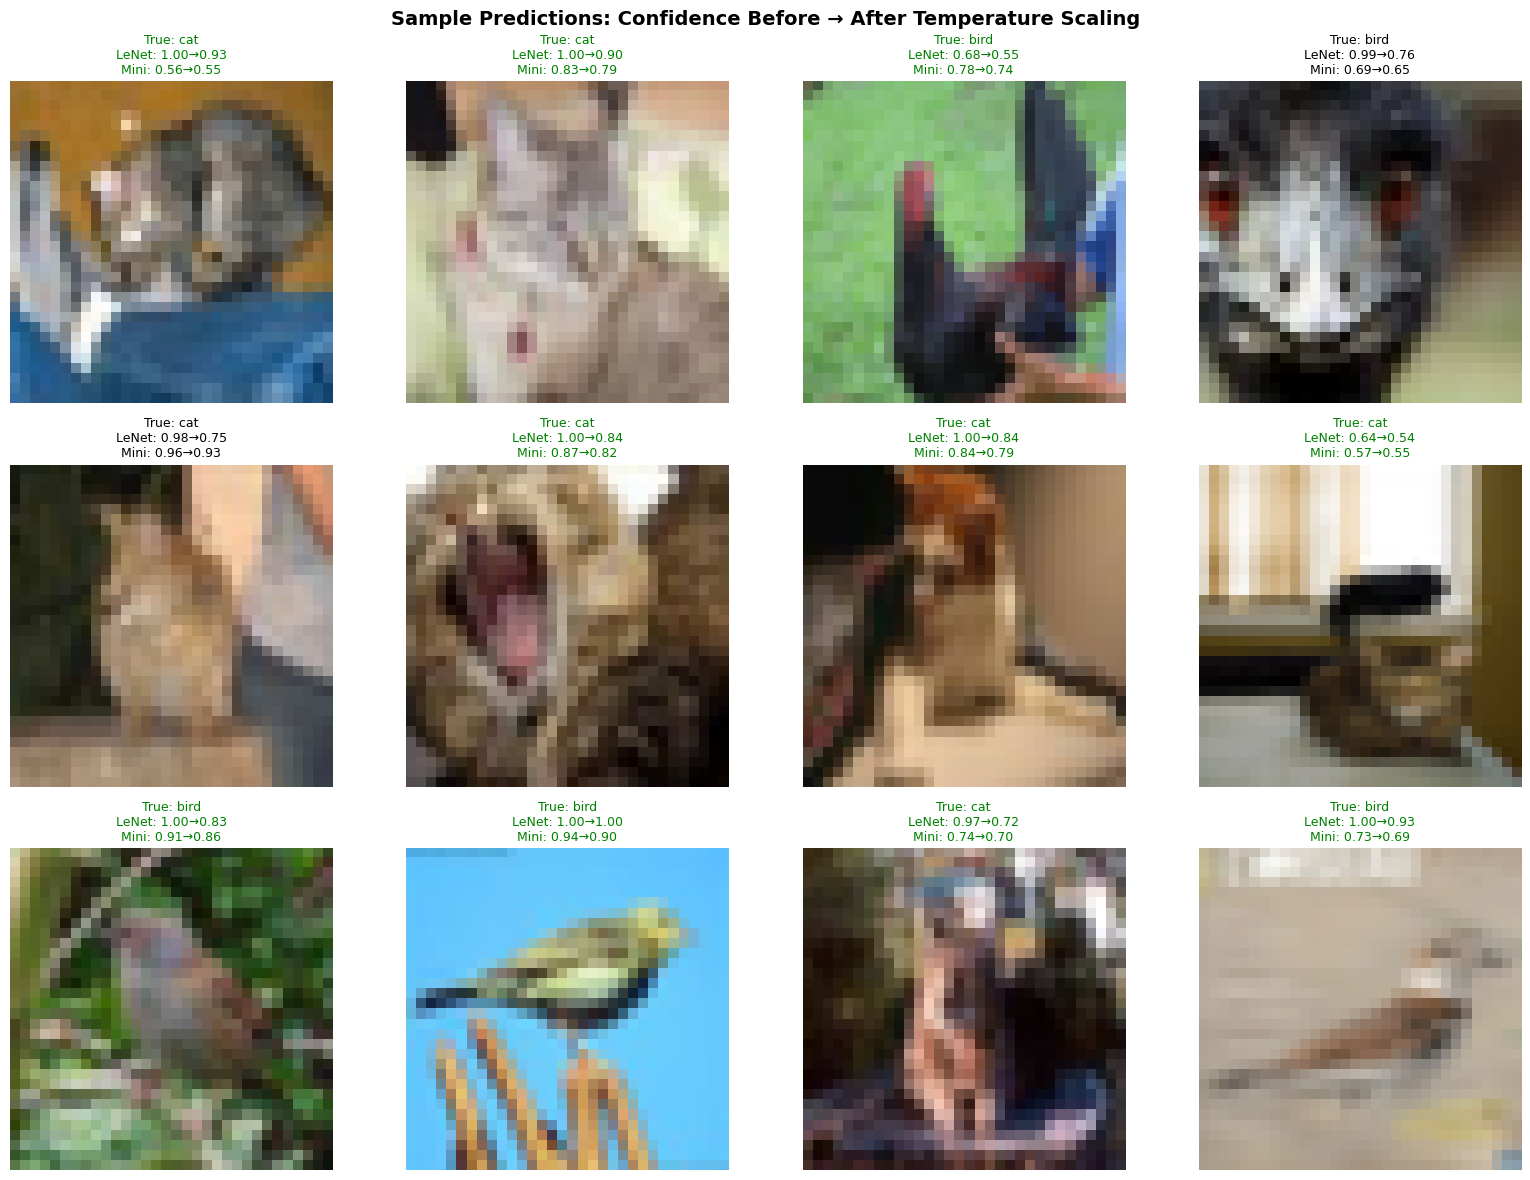


Showing 12 random test samples with confidence changes
LeNet-5 uses T=3.71, Mini-LeNet uses T=1.23


In [37]:
# Visualize prediction samples with confidence for both models
print("=" * 80)
print("SAMPLE PREDICTIONS VISUALIZATION")
print("=" * 80)

# Get a batch of test samples
dataiter = iter(test_loader)
sample_images, sample_labels = next(dataiter)
sample_images = sample_images[:12]
sample_labels = sample_labels[:12].numpy()

# Get predictions from both models
# LeNet-5
model.eval()
with torch.no_grad():
    lenet_logits = model.get_logits(sample_images.to(device))
    lenet_probs_before = F.softmax(lenet_logits, dim=1).cpu().numpy()
    lenet_probs_after = F.softmax(lenet_logits / lenet_temperature_optimal, dim=1).cpu().numpy()

# Mini-LeNet  
mini_model.eval()
with torch.no_grad():
    mini_logits = mini_model(sample_images.to(device))
    mini_probs_before = F.softmax(mini_logits, dim=1).cpu().numpy()
    mini_probs_after = F.softmax(mini_logits / mini_temperature_optimal, dim=1).cpu().numpy()

# Create visualization
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(12):
    ax = axes[i]
    
    # Display image
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5  # Denormalize
    ax.imshow(img)
    ax.axis('off')
    
    true_label = class_names_binary[sample_labels[i]]
    
    # LeNet-5 predictions
    lenet_pred_before = np.argmax(lenet_probs_before[i])
    lenet_conf_before = np.max(lenet_probs_before[i])
    lenet_pred_after = np.argmax(lenet_probs_after[i])
    lenet_conf_after = np.max(lenet_probs_after[i])
    
    # Mini-LeNet predictions
    mini_pred_before = np.argmax(mini_probs_before[i])
    mini_conf_before = np.max(mini_probs_before[i])
    mini_pred_after = np.argmax(mini_probs_after[i])
    mini_conf_after = np.max(mini_probs_after[i])
    
    # Create title with color coding
    lenet_color = 'green' if lenet_pred_before == sample_labels[i] else 'red'
    mini_color = 'green' if mini_pred_before == sample_labels[i] else 'red'
    
    title = f"True: {true_label}\n"
    title += f"LeNet: {lenet_conf_before:.2f}→{lenet_conf_after:.2f}\n"
    title += f"Mini: {mini_conf_before:.2f}→{mini_conf_after:.2f}"
    
    ax.set_title(title, fontsize=9, color=lenet_color if lenet_pred_before == sample_labels[i] else 'black')

plt.suptitle('Sample Predictions: Confidence Before → After Temperature Scaling', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nShowing 12 random test samples with confidence changes")
print(f"LeNet-5 uses T={lenet_temperature_optimal:.2f}, Mini-LeNet uses T={mini_temperature_optimal:.2f}")


CALIBRATION CURVES COMPARISON


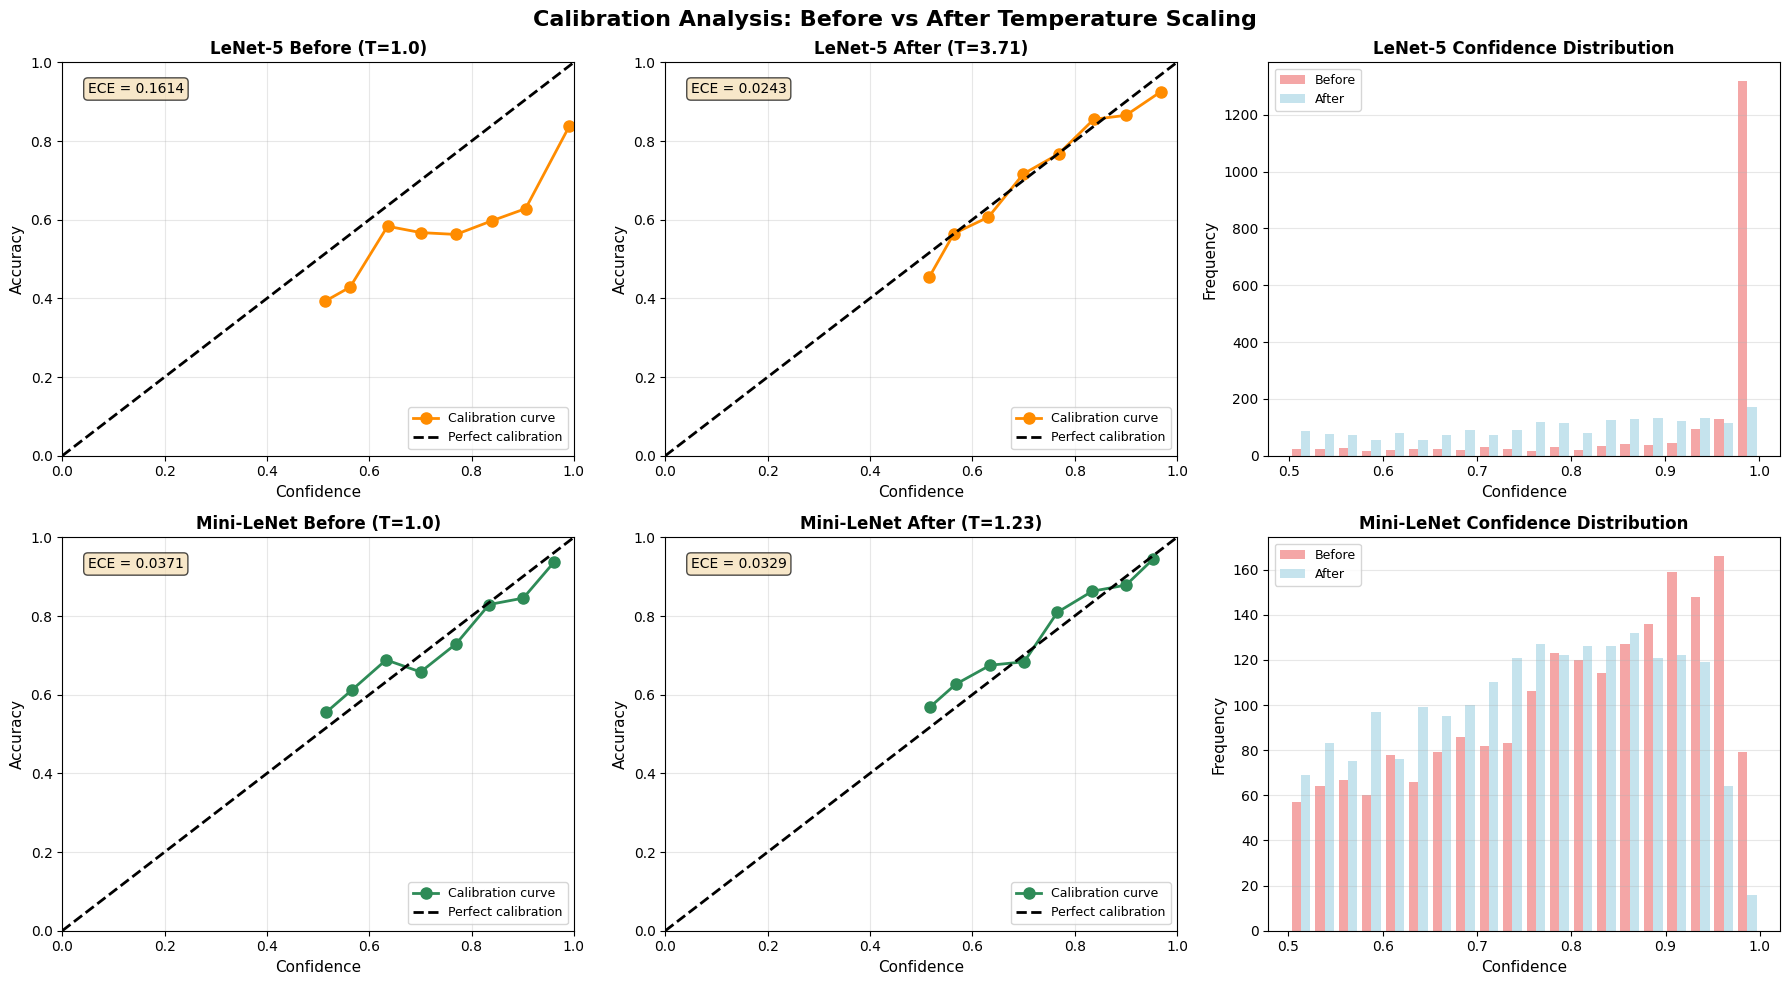


Calibration curves use our calculate_ece() function with 15 bins
This ensures consistency with ECE calculations throughout the notebook
LeNet-5: ECE 0.1614 → 0.0243
Mini-LeNet: ECE 0.0371 → 0.0329


In [38]:
# Compare calibration curves for both models using our own calculate_ece function
print("\n" + "=" * 80)
print("CALIBRATION CURVES COMPARISON")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Helper function to plot calibration curve using our own binning method
def plot_calibration_curve_custom(ax, confidences, predictions, labels, title, color, n_bins=15):
    """
    Plot calibration curve using the same calculate_ece function we defined earlier.
    This ensures consistency with our ECE calculations.
    """
    ece, bin_accs, bin_confs, bin_counts = calculate_ece(confidences, predictions, labels, n_bins=n_bins)
    
    # Only plot bins with data
    mask = bin_counts > 0
    
    # Plot calibration curve
    ax.plot(bin_confs[mask], bin_accs[mask], 
            'o-', color=color, linewidth=2, markersize=8, label='Calibration curve')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect calibration')
    
    # Add ECE annotation
    ax.text(0.05, 0.95, f'ECE = {ece:.4f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    ax.set_xlabel('Confidence', fontsize=11)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

# LeNet-5 calibration curves
plot_calibration_curve_custom(axes[0, 0], lenet_confidences_baseline, lenet_predictions_baseline,
                               lenet_labels_test, 'LeNet-5 Before (T=1.0)', '#FF8C00')
plot_calibration_curve_custom(axes[0, 1], lenet_confidences_calibrated, lenet_predictions_calibrated,
                               lenet_labels_calibrated, f'LeNet-5 After (T={lenet_temperature_optimal:.2f})', '#FF8C00')

# Confidence distributions for LeNet-5
axes[0, 2].hist([lenet_confidences_baseline, lenet_confidences_calibrated], 
                bins=20, label=['Before', 'After'], alpha=0.7, color=['lightcoral', 'lightblue'])
axes[0, 2].set_xlabel('Confidence', fontsize=11)
axes[0, 2].set_ylabel('Frequency', fontsize=11)
axes[0, 2].set_title('LeNet-5 Confidence Distribution', fontsize=12, fontweight='bold')
axes[0, 2].legend(fontsize=9)
axes[0, 2].grid(alpha=0.3, axis='y')

# Mini-LeNet calibration curves
plot_calibration_curve_custom(axes[1, 0], mini_confidences_baseline, mini_predictions_baseline,
                               mini_labels_test, 'Mini-LeNet Before (T=1.0)', '#2E8B57')
plot_calibration_curve_custom(axes[1, 1], mini_confidences_calibrated, mini_predictions_calibrated,
                               mini_labels_calibrated, f'Mini-LeNet After (T={mini_temperature_optimal:.2f})', '#2E8B57')

# Confidence distributions for Mini-LeNet
axes[1, 2].hist([mini_confidences_baseline, mini_confidences_calibrated], 
                bins=20, label=['Before', 'After'], alpha=0.7, color=['lightcoral', 'lightblue'])
axes[1, 2].set_xlabel('Confidence', fontsize=11)
axes[1, 2].set_ylabel('Frequency', fontsize=11)
axes[1, 2].set_title('Mini-LeNet Confidence Distribution', fontsize=12, fontweight='bold')
axes[1, 2].legend(fontsize=9)
axes[1, 2].grid(alpha=0.3, axis='y')

plt.suptitle('Calibration Analysis: Before vs After Temperature Scaling', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nCalibration curves use our calculate_ece() function with 15 bins")
print(f"This ensures consistency with ECE calculations throughout the notebook")
print(f"LeNet-5: ECE {lenet_ece_baseline:.4f} → {lenet_ece_calibrated:.4f}")
print(f"Mini-LeNet: ECE {mini_ece_baseline:.4f} → {mini_ece_calibrated:.4f}")


FINAL SUMMARY VISUALIZATION


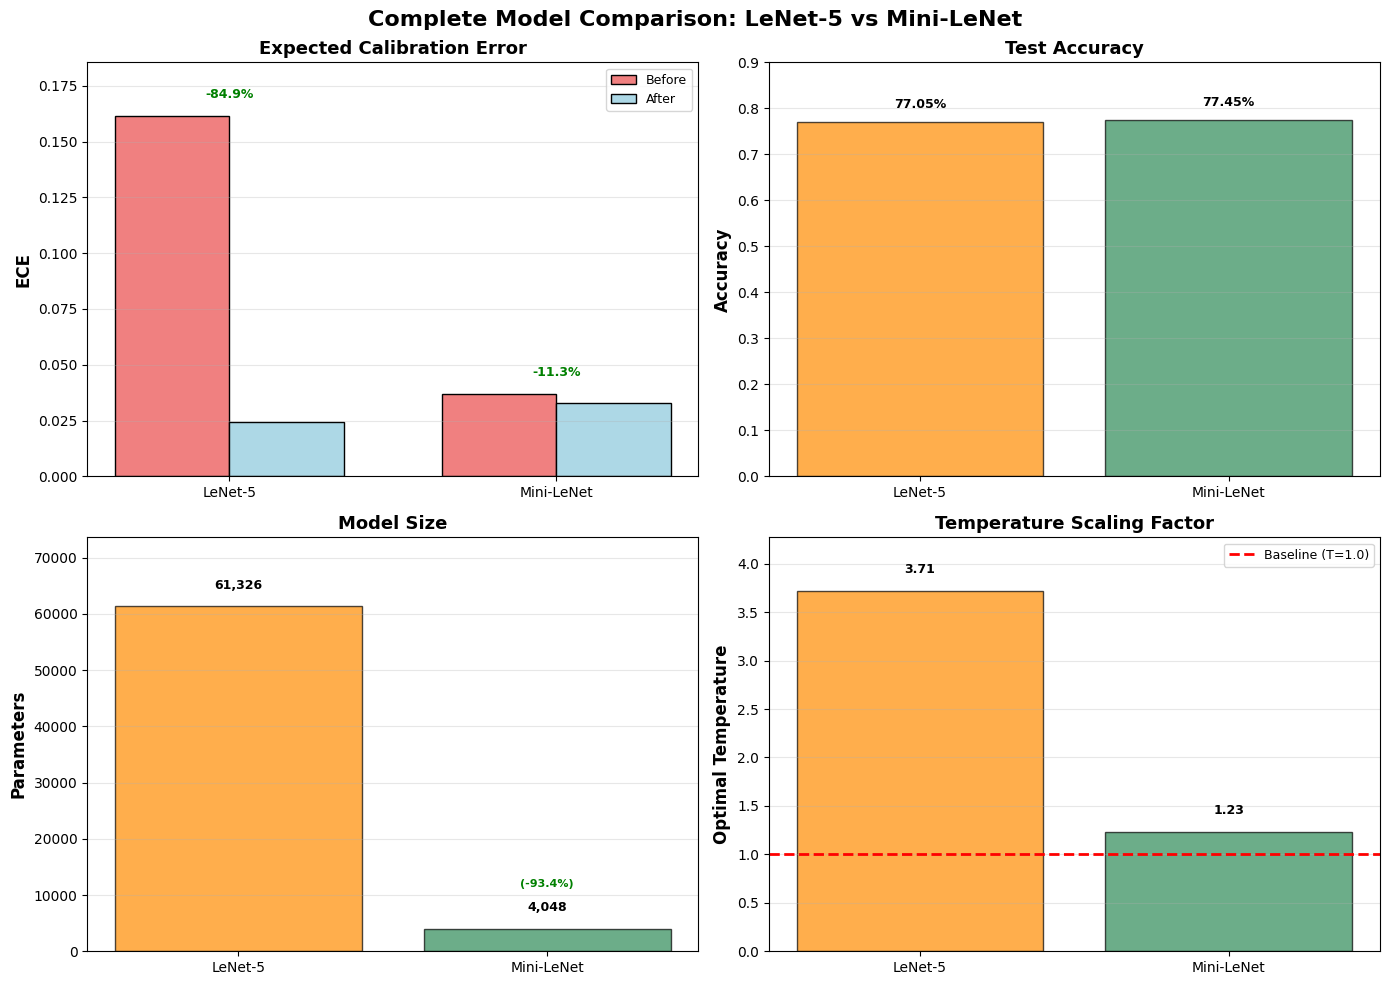

In [40]:
# Final summary comparison
print("\n" + "=" * 80)
print("FINAL SUMMARY VISUALIZATION")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Model metrics comparison
models = ['LeNet-5', 'Mini-LeNet']
ece_before = [lenet_ece_baseline, mini_ece_baseline]
ece_after = [lenet_ece_calibrated, mini_ece_calibrated]
accuracy = [lenet_accuracy_test, mini_accuracy_test]
params = [61326, 4048]

# ECE comparison
ax = axes[0, 0]
x = np.arange(len(models))
width = 0.35
ax.bar(x - width/2, ece_before, width, label='Before', color='lightcoral', edgecolor='black')
ax.bar(x + width/2, ece_after, width, label='After', color='lightblue', edgecolor='black')
ax.set_ylabel('ECE', fontsize=12, fontweight='bold')
ax.set_title('Expected Calibration Error', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
# Set y-axis limit to accommodate text
ax.set_ylim([0, max(ece_before) * 1.15])

# ECE reduction percentage - position above bars
for i, (before, after) in enumerate(zip(ece_before, ece_after)):
    reduction = ((before - after) / before) * 100
    y_pos = max(before, after) + max(ece_before) * 0.05
    ax.text(i, y_pos, f'-{reduction:.1f}%', 
            ha='center', fontsize=9, fontweight='bold', color='green')

# Accuracy comparison
ax = axes[0, 1]
ax.bar(models, accuracy, color=['#FF8C00', '#2E8B57'], edgecolor='black', alpha=0.7)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Test Accuracy', fontsize=13, fontweight='bold')
ax.set_ylim([0, 0.9])
ax.grid(alpha=0.3, axis='y')
for i, acc in enumerate(accuracy):
    ax.text(i, acc + 0.03, f'{acc:.2%}', ha='center', fontsize=9, fontweight='bold')

# Parameters comparison
ax = axes[1, 0]
bars = ax.bar(models, params, color=['#FF8C00', '#2E8B57'], edgecolor='black', alpha=0.7)
ax.set_ylabel('Parameters', fontsize=12, fontweight='bold')
ax.set_title('Model Size', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
# Set y-axis limit to accommodate text
ax.set_ylim([0, max(params) * 1.2])
for i, param in enumerate(params):
    # Position text above bars
    y_pos = param + max(params) * 0.05
    ax.text(i, y_pos, f'{param:,}', ha='center', fontsize=9, fontweight='bold')
    if i == 1:
        reduction = ((params[0] - params[1]) / params[0]) * 100
        y_pos2 = param + max(params) * 0.12
        ax.text(i, y_pos2, f'(-93.4%)', ha='center', 
                fontsize=8, color='green', fontweight='bold')

# Temperature values
ax = axes[1, 1]
temps = [lenet_temperature_optimal, mini_temperature_optimal]
colors = ['#FF8C00', '#2E8B57']
ax.bar(models, temps, color=colors, edgecolor='black', alpha=0.7)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Baseline (T=1.0)')
ax.set_ylabel('Optimal Temperature', fontsize=12, fontweight='bold')
ax.set_title('Temperature Scaling Factor', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
# Set y-axis limit to accommodate text
ax.set_ylim([0, max(temps) * 1.15])
for i, temp in enumerate(temps):
    y_pos = temp + max(temps) * 0.05
    ax.text(i, y_pos, f'{temp:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Complete Model Comparison: LeNet-5 vs Mini-LeNet', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. (Optional) Pre-trained Model Experiment

Repeat the calibration study with a larger pre-trained model (e.g., ResNet, VGG).

We'll compare three pretrained models across different parameter scales:
1. **MobileNet-V3-Small**: ~2.5M parameters (lightweight)
2. **ResNet-18**: ~11M parameters (medium) 
3. **VGG-16**: ~138M parameters (large)

This scale analysis validates the paper's finding that larger networks are more poorly calibrated despite higher accuracy.

**Goal**: Compare calibration of LeNet-5 vs. a modern pre-trained architecture to validate the paper's finding that larger networks can be even more poorly calibrated despite higher accuracy.

### 9.1 MobileNet-V3-Small (Lightweight Model)

#### 9.1.1 Load and Adapt MobileNet-V3-Small

In [41]:
import torchvision.models as models
from torch import nn, optim

# Load pre-trained MobileNet-V3-Small (ImageNet weights)
mobilenet = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

# Freeze all layers except final classifier
for param in mobilenet.parameters():
    param.requires_grad = False

# Adapt final classifier for binary classification
num_features = mobilenet.classifier[3].in_features
mobilenet.classifier[3] = nn.Linear(num_features, 2)

mobilenet = mobilenet.to(device)

# Count parameters
mobilenet_params_total = sum(p.numel() for p in mobilenet.parameters())
mobilenet_params_trainable = sum(p.numel() for p in mobilenet.parameters() if p.requires_grad)

print(f"MobileNet-V3-Small Configuration:")
print(f"  Total parameters: {mobilenet_params_total:,}")
print(f"  Trainable parameters: {mobilenet_params_trainable:,}")


MobileNet-V3-Small Configuration:
  Total parameters: 1,519,906
  Trainable parameters: 2,050


#### 9.1.2 Train MobileNet-V3-Small

In [42]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss()
optimizer_mobilenet = optim.Adam(filter(lambda p: p.requires_grad, mobilenet.parameters()), lr=0.001)
scheduler_mobilenet = ReduceLROnPlateau(optimizer_mobilenet, mode='min', factor=0.5, patience=5)

num_epochs_mobilenet = 80
mobilenet_loss_train = []
mobilenet_loss_val = []
mobilenet_acc_train = []
mobilenet_acc_val = []

for epoch in range(num_epochs_mobilenet):
    # Training phase
    mobilenet.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer_mobilenet.zero_grad()
        outputs = mobilenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_mobilenet.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total
    mobilenet_loss_train.append(train_loss)
    mobilenet_acc_train.append(train_acc)
    
    # Validation phase
    mobilenet.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mobilenet(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total
    mobilenet_loss_val.append(val_loss)
    mobilenet_acc_val.append(val_acc)
    
    scheduler_mobilenet.step(val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == num_epochs_mobilenet - 1:
        print(f"Epoch [{epoch+1}/{num_epochs_mobilenet}] "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

print(f"\nTraining completed")
print(f"Final Training Accuracy: {mobilenet_acc_train[-1]:.2f}%")
print(f"Final Validation Accuracy: {mobilenet_acc_val[-1]:.2f}%")


Epoch [1/80] Train Loss: 0.7628, Acc: 60.17% | Val Loss: 0.6499, Acc: 64.60%
Epoch [5/80] Train Loss: 0.6691, Acc: 63.98% | Val Loss: 0.6665, Acc: 64.95%
Epoch [5/80] Train Loss: 0.6691, Acc: 63.98% | Val Loss: 0.6665, Acc: 64.95%
Epoch [10/80] Train Loss: 0.6436, Acc: 64.92% | Val Loss: 0.6313, Acc: 66.80%
Epoch [10/80] Train Loss: 0.6436, Acc: 64.92% | Val Loss: 0.6313, Acc: 66.80%
Epoch [15/80] Train Loss: 0.6276, Acc: 65.71% | Val Loss: 0.6304, Acc: 65.65%
Epoch [15/80] Train Loss: 0.6276, Acc: 65.71% | Val Loss: 0.6304, Acc: 65.65%
Epoch [20/80] Train Loss: 0.6162, Acc: 66.96% | Val Loss: 0.6271, Acc: 65.35%
Epoch [20/80] Train Loss: 0.6162, Acc: 66.96% | Val Loss: 0.6271, Acc: 65.35%
Epoch [25/80] Train Loss: 0.6138, Acc: 66.72% | Val Loss: 0.6154, Acc: 65.80%
Epoch [25/80] Train Loss: 0.6138, Acc: 66.72% | Val Loss: 0.6154, Acc: 65.80%
Epoch [30/80] Train Loss: 0.6176, Acc: 66.24% | Val Loss: 0.6182, Acc: 67.20%
Epoch [30/80] Train Loss: 0.6176, Acc: 66.24% | Val Loss: 0.6182, A

#### 9.1.3 Evaluate MobileNet Baseline Calibration

MobileNet Baseline Calibration:
  Test Accuracy: 66.80%
  ECE: 0.0214
  NLL: 0.6095
  Average Confidence: 0.6651
  Confidence - Accuracy Gap: -0.0029


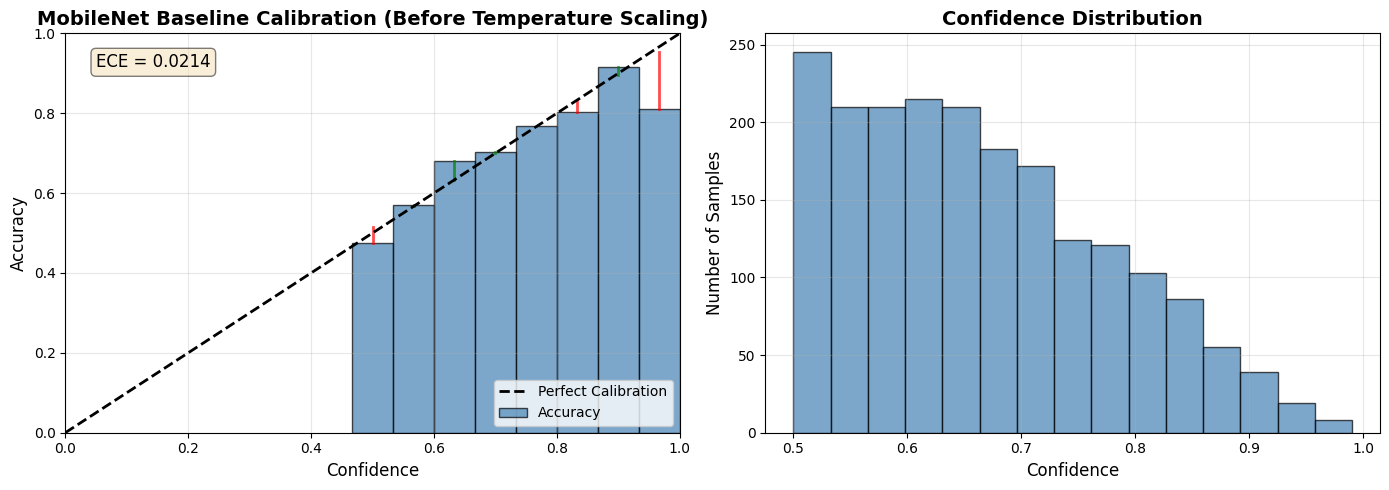


Calibration Statistics by Confidence Bin:
----------------------------------------------------------------------
Bin Range       Count      Accuracy     Confidence   Gap       
----------------------------------------------------------------------
0.47-0.53     250        0.4760       0.5161       0.0401    
0.53-0.60     425        0.5694       0.5666       0.0028    
0.60-0.67     438        0.6804       0.6333       0.0471    
0.67-0.73     353        0.7025       0.6998       0.0028    
0.73-0.80     249        0.7671       0.7671       0.0000    
0.80-0.87     182        0.8022       0.8320       0.0298    
0.87-0.93     82         0.9146       0.8957       0.0189    
0.93-1.00     21         0.8095       0.9544       0.1449    
----------------------------------------------------------------------


In [46]:
# Extract predictions and confidences from test set
mobilenet.eval()
all_logits_mobilenet = []
all_labels_mobilenet = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = mobilenet(images)
        all_logits_mobilenet.append(logits.cpu())
        all_labels_mobilenet.append(labels)

mobilenet_logits_test = torch.cat(all_logits_mobilenet).numpy()
mobilenet_labels_test = torch.cat(all_labels_mobilenet).numpy()

# Baseline predictions (temperature = 1.0)
mobilenet_probabilities_baseline = torch.softmax(torch.tensor(mobilenet_logits_test), dim=1).numpy()
mobilenet_confidences_baseline = np.max(mobilenet_probabilities_baseline, axis=1)
mobilenet_predictions_baseline = np.argmax(mobilenet_probabilities_baseline, axis=1)

# Calculate metrics
mobilenet_accuracy_test = np.mean(mobilenet_predictions_baseline == mobilenet_labels_test) * 100

mobilenet_ece_baseline, mobilenet_bin_accs_baseline, mobilenet_bin_confs_baseline, mobilenet_bin_counts_baseline = calculate_ece(
    mobilenet_confidences_baseline, mobilenet_predictions_baseline, mobilenet_labels_test, n_bins=15
)

# Calculate NLL
mobilenet_nll_baseline = F.cross_entropy(torch.tensor(mobilenet_logits_test), torch.tensor(mobilenet_labels_test, dtype=torch.long), reduction='mean').item()

print(f"MobileNet Baseline Calibration:")
print(f"  Test Accuracy: {mobilenet_accuracy_test:.2f}%")
print(f"  ECE: {mobilenet_ece_baseline:.4f}")
print(f"  NLL: {mobilenet_nll_baseline:.4f}")
print(f"  Average Confidence: {np.mean(mobilenet_confidences_baseline):.4f}")
print(f"  Confidence - Accuracy Gap: {np.mean(mobilenet_confidences_baseline) - mobilenet_accuracy_test/100:.4f}")

# Reliability diagram
mobilenet_ece_baseline_plot = plot_reliability_diagram(
    mobilenet_confidences_baseline, mobilenet_predictions_baseline, mobilenet_labels_test, n_bins=15,
    title="MobileNet Baseline Calibration (Before Temperature Scaling)"
)

# Bin statistics
print("\nCalibration Statistics by Confidence Bin:")
print("-" * 70)
print(f"{'Bin Range':<15} {'Count':<10} {'Accuracy':<12} {'Confidence':<12} {'Gap':<10}")
print("-" * 70)

bin_boundaries = np.linspace(0, 1, 16)
for i in range(15):
    if mobilenet_bin_counts_baseline[i] > 0:
        gap = abs(mobilenet_bin_accs_baseline[i] - mobilenet_bin_confs_baseline[i])
        print(f"{bin_boundaries[i]:.2f}-{bin_boundaries[i+1]:.2f}     "
              f"{int(mobilenet_bin_counts_baseline[i]):<10} {mobilenet_bin_accs_baseline[i]:<12.4f} "
              f"{mobilenet_bin_confs_baseline[i]:<12.4f} {gap:<10.4f}")

print("-" * 70)

#### 9.1.4 Optimize Temperature Scaling for MobileNet

Optimal Temperature: 1.10
NLL at optimal T (validation): 0.6092

Calibrated ECE (test set): 0.0308
ECE Reduction: -0.0093 (-43.5%)


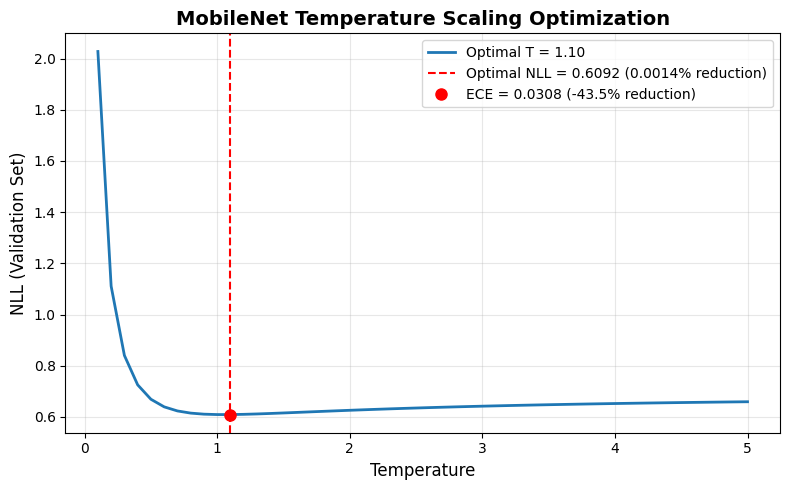

In [51]:
# Get validation set logits
mobilenet.eval()
mobilenet_logits_val = []
mobilenet_labels_val = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        logits = mobilenet(images)
        mobilenet_logits_val.append(logits.cpu())
        mobilenet_labels_val.append(labels)

mobilenet_logits_val = torch.cat(mobilenet_logits_val).numpy()
mobilenet_labels_val = torch.cat(mobilenet_labels_val).numpy()

# Search for optimal temperature
mobilenet_temp_range = np.linspace(0.1, 5.0, 50)
mobilenet_ece_values_temp_sweep = []
mobilenet_nll_values_temp_sweep = []

for temp in mobilenet_temp_range:
    scaled_logits = mobilenet_logits_val / temp
    probs_temp = torch.softmax(torch.tensor(scaled_logits), dim=1).numpy()
    confs_temp = np.max(probs_temp, axis=1)
    preds_temp = np.argmax(probs_temp, axis=1)
    ece_temp, _, _, _ = calculate_ece(confs_temp, preds_temp, mobilenet_labels_val, n_bins=15)
    nll_temp = F.cross_entropy(torch.tensor(scaled_logits), torch.tensor(mobilenet_labels_val, dtype=torch.long), reduction='mean').item()
    mobilenet_ece_values_temp_sweep.append(ece_temp)
    mobilenet_nll_values_temp_sweep.append(nll_temp)

optimal_idx_mobilenet = np.argmin(mobilenet_nll_values_temp_sweep)
mobilenet_temperature_optimal = mobilenet_temp_range[optimal_idx_mobilenet]

baseline_idx = np.argmin(np.abs(mobilenet_temp_range - 1.0))
nll_baseline = mobilenet_nll_values_temp_sweep[baseline_idx]
nll_optimal = mobilenet_nll_values_temp_sweep[optimal_idx_mobilenet]
nll_reduction = (nll_baseline - nll_optimal) / nll_baseline * 100

ece_reduction = (mobilenet_ece_baseline - mobilenet_ece_calibrated) / mobilenet_ece_baseline * 100

print(f"Optimal Temperature: {mobilenet_temperature_optimal:.2f}")
print(f"NLL at optimal T (validation): {mobilenet_nll_values_temp_sweep[optimal_idx_mobilenet]:.4f}")

# Apply temperature scaling to test set
mobilenet_logits_test_scaled = mobilenet_logits_test / mobilenet_temperature_optimal
mobilenet_probabilities_calibrated = torch.softmax(torch.tensor(mobilenet_logits_test_scaled), dim=1).numpy()
mobilenet_confidences_calibrated = np.max(mobilenet_probabilities_calibrated, axis=1)
mobilenet_predictions_calibrated = np.argmax(mobilenet_probabilities_calibrated, axis=1)

mobilenet_ece_calibrated, mobilenet_bin_accs_calibrated, mobilenet_bin_confs_calibrated, mobilenet_bin_counts_calibrated = calculate_ece(
    mobilenet_confidences_calibrated, mobilenet_predictions_calibrated, mobilenet_labels_test, n_bins=15
)

print(f"\nCalibrated ECE (test set): {mobilenet_ece_calibrated:.4f}")
print(f"ECE Reduction: {(mobilenet_ece_baseline - mobilenet_ece_calibrated):.4f} ({100*(mobilenet_ece_baseline - mobilenet_ece_calibrated)/mobilenet_ece_baseline:.1f}%)")

# Temperature search curve
plt.figure(figsize=(8, 5))
plt.plot(mobilenet_temp_range, mobilenet_nll_values_temp_sweep, linewidth=2)
plt.axvline(mobilenet_temperature_optimal, color='red', linestyle='--')
plt.plot(mobilenet_temperature_optimal, mobilenet_nll_values_temp_sweep[optimal_idx_mobilenet], 'ro', markersize=8)
plt.xlabel('Temperature', fontsize=12)
plt.ylabel('NLL (Validation Set)', fontsize=12)
plt.title('MobileNet Temperature Scaling Optimization', fontsize=14, fontweight='bold')
plt.legend([
    f'Optimal T = {mobilenet_temperature_optimal:.2f}',
    f'Optimal NLL = {mobilenet_nll_values_temp_sweep[optimal_idx_mobilenet]:.4f} ({nll_reduction:.4f}% reduction)',
    f'ECE = {mobilenet_ece_calibrated:.4f} ({ece_reduction:.1f}% reduction)'
])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 9.2 ResNet-18 (Medium Model)

ResNet-18 is a medium-sized architecture with ~11M parameters, representing the middle of our scale analysis. ResNet introduced residual connections that help with deep network training.

#### 9.2.1 Load and Adapt ResNet-18

#### 9.2.2 Train ResNet-18

In [52]:
import torchvision.models as models
from torch import nn, optim

# Load pre-trained ResNet-18 (ImageNet weights)
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze all layers except final classifier
for param in resnet.parameters():
    param.requires_grad = False

# Adapt final fully connected layer for binary classification
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 2)

resnet = resnet.to(device)

# Count parameters
resnet_params_total = sum(p.numel() for p in resnet.parameters())
resnet_params_trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)

print(f"ResNet-18 Configuration:")
print(f"  Total parameters: {resnet_params_total:,}")
print(f"  Trainable parameters: {resnet_params_trainable:,}")


ResNet-18 Configuration:
  Total parameters: 11,177,538
  Trainable parameters: 1,026


In [54]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(resnet.fc.parameters(), lr=0.001)
scheduler_resnet = ReduceLROnPlateau(optimizer_resnet, mode='min', factor=0.5, patience=5)

num_epochs_resnet = 80
resnet_loss_train = []
resnet_loss_val = []
resnet_acc_train = []
resnet_acc_val = []

for epoch in range(num_epochs_resnet):
    # Training phase
    resnet.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer_resnet.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_resnet.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total
    resnet_loss_train.append(train_loss)
    resnet_acc_train.append(train_acc)
    
    # Validation phase
    resnet.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total
    resnet_loss_val.append(val_loss)
    resnet_acc_val.append(val_acc)
    
    scheduler_resnet.step(val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == num_epochs_resnet - 1:
        print(f"Epoch [{epoch+1}/{num_epochs_resnet}] "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

print(f"\nTraining completed")
print(f"Final Training Accuracy: {resnet_acc_train[-1]:.2f}%")
print(f"Final Validation Accuracy: {resnet_acc_val[-1]:.2f}%")


Epoch [1/80] Train Loss: 0.5767, Acc: 70.31% | Val Loss: 0.4954, Acc: 76.65%
Epoch [5/80] Train Loss: 0.4680, Acc: 78.33% | Val Loss: 0.4706, Acc: 78.55%
Epoch [5/80] Train Loss: 0.4680, Acc: 78.33% | Val Loss: 0.4706, Acc: 78.55%
Epoch [10/80] Train Loss: 0.4590, Acc: 79.08% | Val Loss: 0.4651, Acc: 78.50%
Epoch [10/80] Train Loss: 0.4590, Acc: 79.08% | Val Loss: 0.4651, Acc: 78.50%
Epoch [15/80] Train Loss: 0.4548, Acc: 79.09% | Val Loss: 0.4660, Acc: 77.85%
Epoch [15/80] Train Loss: 0.4548, Acc: 79.09% | Val Loss: 0.4660, Acc: 77.85%
Epoch [20/80] Train Loss: 0.4473, Acc: 79.47% | Val Loss: 0.4676, Acc: 77.95%
Epoch [20/80] Train Loss: 0.4473, Acc: 79.47% | Val Loss: 0.4676, Acc: 77.95%
Epoch [25/80] Train Loss: 0.4412, Acc: 79.79% | Val Loss: 0.4643, Acc: 78.15%
Epoch [25/80] Train Loss: 0.4412, Acc: 79.79% | Val Loss: 0.4643, Acc: 78.15%
Epoch [30/80] Train Loss: 0.4465, Acc: 79.22% | Val Loss: 0.4634, Acc: 78.30%
Epoch [30/80] Train Loss: 0.4465, Acc: 79.22% | Val Loss: 0.4634, A

#### 9.2.3 Evaluate ResNet Baseline Calibration

ResNet-18 Baseline Calibration:
  Test Accuracy: 77.85%
  ECE: 0.0250
  Average Confidence: 0.7884
  Confidence - Accuracy Gap: 0.0099


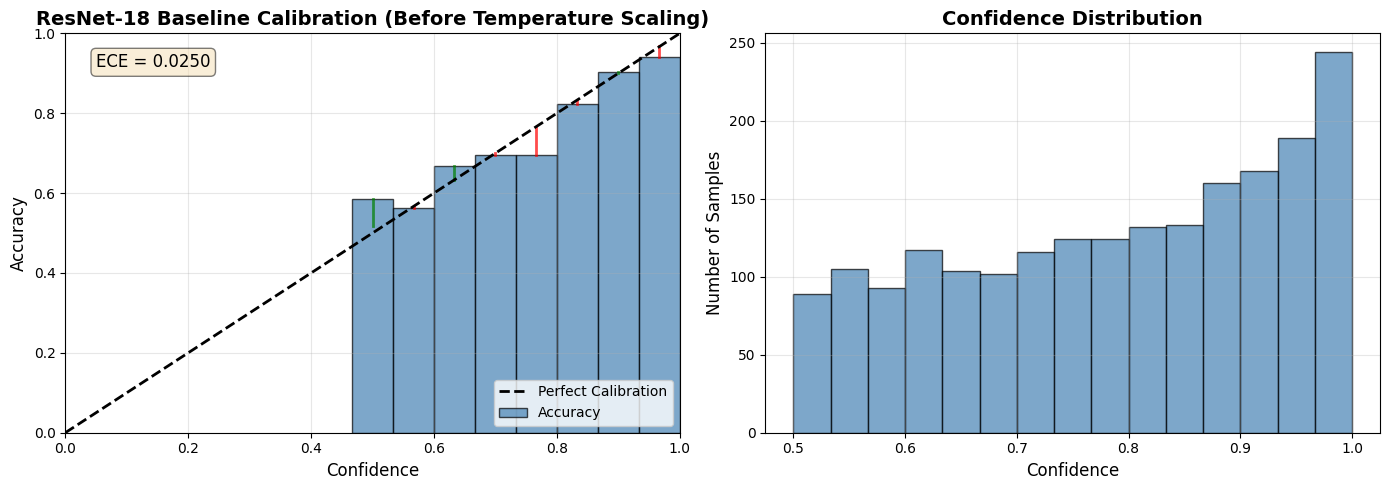


Calibration Statistics by Confidence Bin:
----------------------------------------------------------------------
Bin Range       Count      Accuracy     Confidence   Gap       
----------------------------------------------------------------------
0.47-0.53     87         0.5862       0.5165       0.0697    
0.53-0.60     199        0.5628       0.5661       0.0033    
0.60-0.67     220        0.6682       0.6317       0.0365    
0.67-0.73     220        0.6955       0.7011       0.0056    
0.73-0.80     247        0.6964       0.7667       0.0704    
0.80-0.87     266        0.8233       0.8339       0.0106    
0.87-0.93     329        0.9027       0.8999       0.0028    
0.93-1.00     432        0.9398       0.9694       0.0296    
----------------------------------------------------------------------


In [55]:
# Extract predictions and confidences from test set
all_confidences_resnet = []
all_predictions_resnet = []
all_logits_resnet = []
all_labels_resnet = []

resnet.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = resnet(images)
        probs = torch.softmax(logits, dim=1)
        confidences, predictions = torch.max(probs, dim=1)
        
        all_confidences_resnet.append(confidences.cpu().numpy())
        all_predictions_resnet.append(predictions.cpu().numpy())
        all_logits_resnet.append(logits.cpu().numpy())
        all_labels_resnet.append(labels.numpy())

resnet_confidences_baseline = np.concatenate(all_confidences_resnet)
resnet_predictions_baseline = np.concatenate(all_predictions_resnet)
resnet_logits_test = np.concatenate(all_logits_resnet)
resnet_labels_test = np.concatenate(all_labels_resnet)

# Calculate metrics
resnet_accuracy_test = np.mean(resnet_predictions_baseline == resnet_labels_test)

resnet_ece_baseline, resnet_bin_accs_baseline, resnet_bin_confs_baseline, resnet_bin_counts_baseline = calculate_ece(
    resnet_confidences_baseline, resnet_predictions_baseline, resnet_labels_test, n_bins=15
)

print(f"ResNet-18 Baseline Calibration:")
print(f"  Test Accuracy: {resnet_accuracy_test*100:.2f}%")
print(f"  ECE: {resnet_ece_baseline:.4f}")
print(f"  Average Confidence: {np.mean(resnet_confidences_baseline):.4f}")
print(f"  Confidence - Accuracy Gap: {np.mean(resnet_confidences_baseline) - resnet_accuracy_test:.4f}")

# Reliability diagram
resnet_ece_baseline_plot = plot_reliability_diagram(
    resnet_confidences_baseline, resnet_predictions_baseline, resnet_labels_test, n_bins=15,
    title="ResNet-18 Baseline Calibration (Before Temperature Scaling)"
)

# Bin statistics
print("\nCalibration Statistics by Confidence Bin:")
print("-" * 70)
print(f"{'Bin Range':<15} {'Count':<10} {'Accuracy':<12} {'Confidence':<12} {'Gap':<10}")
print("-" * 70)

bin_boundaries = np.linspace(0, 1, 16)
for i in range(15):
    if resnet_bin_counts_baseline[i] > 0:
        gap = abs(resnet_bin_accs_baseline[i] - resnet_bin_confs_baseline[i])
        print(f"{bin_boundaries[i]:.2f}-{bin_boundaries[i+1]:.2f}     "
              f"{int(resnet_bin_counts_baseline[i]):<10} {resnet_bin_accs_baseline[i]:<12.4f} "
              f"{resnet_bin_confs_baseline[i]:<12.4f} {gap:<10.4f}")

print("-" * 70)


#### 9.2.4 Optimize Temperature Scaling for ResNet

Optimal Temperature: 1.10
NLL at optimal T (validation): 0.4677


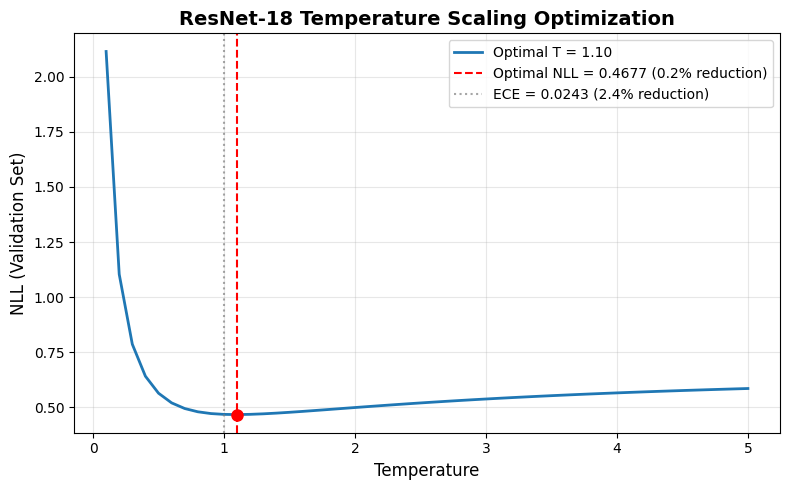

In [57]:
# Get validation set logits
all_logits_resnet_val = []
all_labels_resnet_val = []

resnet.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        logits = resnet(images)
        all_logits_resnet_val.append(logits.cpu().numpy())
        all_labels_resnet_val.append(labels.numpy())

resnet_logits_val = np.concatenate(all_logits_resnet_val)
resnet_labels_val = np.concatenate(all_labels_resnet_val)

# Search for optimal temperature
resnet_temp_range = np.linspace(0.1, 5.0, 50)
resnet_ece_values_temp_sweep = []
resnet_nll_values_temp_sweep = []

for temp in resnet_temp_range:
    probs_T = torch.softmax(torch.from_numpy(resnet_logits_val) / temp, dim=1).numpy()
    conf_T = np.max(probs_T, axis=1)
    pred_T = np.argmax(probs_T, axis=1)
    ece_T, _, _, _ = calculate_ece(conf_T, pred_T, resnet_labels_val, n_bins=15)
    nll_T = F.cross_entropy(torch.from_numpy(resnet_logits_val) / temp, torch.from_numpy(resnet_labels_val).long(), reduction='mean').item()
    resnet_ece_values_temp_sweep.append(ece_T)
    resnet_nll_values_temp_sweep.append(nll_T)

resnet_temperature_optimal = resnet_temp_range[np.argmin(resnet_nll_values_temp_sweep)]
resnet_min_nll_val = np.min(resnet_nll_values_temp_sweep)

baseline_idx_resnet = np.argmin(np.abs(resnet_temp_range - 1.0))
nll_baseline_resnet = resnet_nll_values_temp_sweep[baseline_idx_resnet]
nll_optimal_resnet = resnet_nll_values_temp_sweep[np.argmin(resnet_nll_values_temp_sweep)]
nll_reduction_resnet = (nll_baseline_resnet - nll_optimal_resnet) / nll_baseline_resnet * 100

# Apply temperature scaling to test set
resnet_logits_test_scaled = resnet_logits_test / resnet_temperature_optimal
resnet_probabilities_calibrated = torch.softmax(torch.tensor(resnet_logits_test_scaled), dim=1).numpy()
resnet_confidences_calibrated = np.max(resnet_probabilities_calibrated, axis=1)
resnet_predictions_calibrated = np.argmax(resnet_probabilities_calibrated, axis=1)

resnet_ece_calibrated, _, _, _ = calculate_ece(resnet_confidences_calibrated, resnet_predictions_calibrated, resnet_labels_test, n_bins=15)

ece_reduction_resnet = (resnet_ece_baseline - resnet_ece_calibrated) / resnet_ece_baseline * 100

print(f"Optimal Temperature: {resnet_temperature_optimal:.2f}")
print(f"NLL at optimal T (validation): {resnet_min_nll_val:.4f}")

# Temperature search curve
plt.figure(figsize=(8, 5))
plt.plot(resnet_temp_range, resnet_nll_values_temp_sweep, linewidth=2)
plt.axvline(resnet_temperature_optimal, color='red', linestyle='--')
plt.axvline(1.0, color='gray', linestyle=':', alpha=0.7)
plt.plot(resnet_temperature_optimal, resnet_min_nll_val, 'ro', markersize=8)
plt.xlabel('Temperature', fontsize=12)
plt.ylabel('NLL (Validation Set)', fontsize=12)
plt.title('ResNet-18 Temperature Scaling Optimization', fontsize=14, fontweight='bold')
plt.legend([
    f'Optimal T = {resnet_temperature_optimal:.2f}',
    f'Optimal NLL = {resnet_min_nll_val:.4f} ({nll_reduction_resnet:.1f}% reduction)',
    f'ECE = {resnet_ece_calibrated:.4f} ({ece_reduction_resnet:.1f}% reduction)'
])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ResNet-18 Calibrated Results:
  Test Accuracy: 77.85% (unchanged)
  ECE Before: 0.0250
  ECE After: 0.0243
  ECE Reduction: 2.4%
  Average Confidence Before: 0.7884
  Average Confidence After: 0.7742


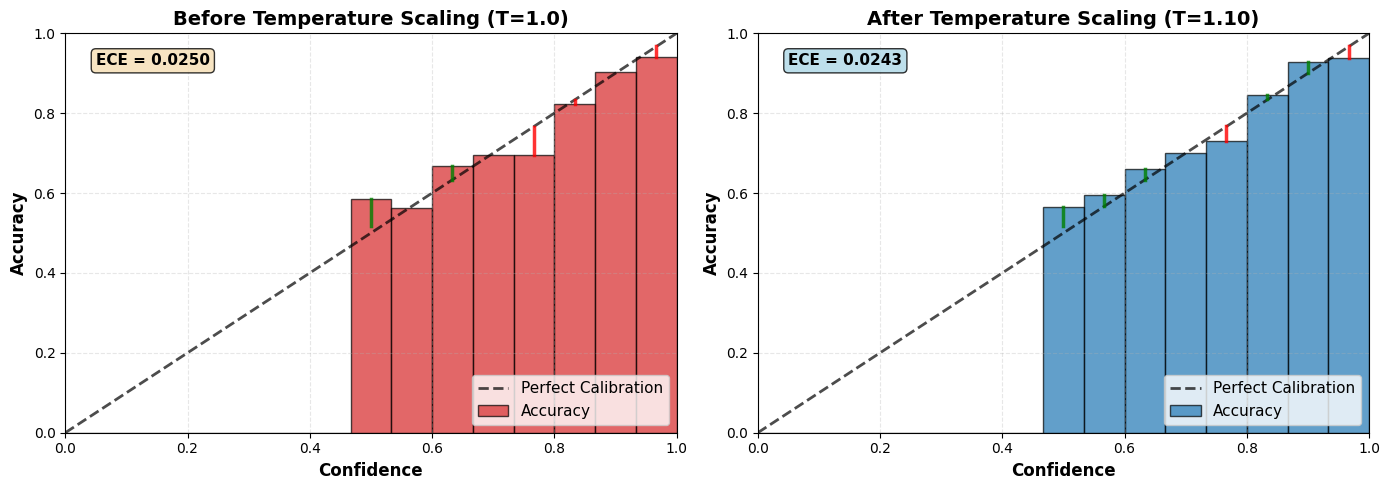

In [58]:
# Apply temperature scaling to test set
resnet_probabilities_calibrated = torch.softmax(torch.from_numpy(resnet_logits_test) / resnet_temperature_optimal, dim=1).numpy()
resnet_confidences_calibrated = np.max(resnet_probabilities_calibrated, axis=1)
resnet_predictions_calibrated = np.argmax(resnet_probabilities_calibrated, axis=1)

resnet_ece_calibrated, resnet_bin_accs_calibrated, resnet_bin_confs_calibrated, resnet_bin_counts_calibrated = calculate_ece(
    resnet_confidences_calibrated, resnet_predictions_calibrated, resnet_labels_test, n_bins=15
)

resnet_accuracy_test_calibrated = np.mean(resnet_predictions_calibrated == resnet_labels_test)
resnet_ece_reduction = ((resnet_ece_baseline - resnet_ece_calibrated) / resnet_ece_baseline) * 100

print(f"ResNet-18 Calibrated Results:")
print(f"  Test Accuracy: {resnet_accuracy_test_calibrated*100:.2f}% (unchanged)")
print(f"  ECE Before: {resnet_ece_baseline:.4f}")
print(f"  ECE After: {resnet_ece_calibrated:.4f}")
print(f"  ECE Reduction: {resnet_ece_reduction:.1f}%")
print(f"  Average Confidence Before: {np.mean(resnet_confidences_baseline):.4f}")
print(f"  Average Confidence After: {np.mean(resnet_confidences_calibrated):.4f}")

# Before/after comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bin_centers = np.linspace(0, 1, 16)[:-1] + 0.5/15
widths = 1.0 / 15

# Before calibration
axes[0].bar(bin_centers, resnet_bin_accs_baseline, width=widths, 
           edgecolor='black', alpha=0.7, label='Accuracy', color='#d62728')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration', alpha=0.7)

for center, acc, conf, count in zip(bin_centers, resnet_bin_accs_baseline, 
                                    resnet_bin_confs_baseline, resnet_bin_counts_baseline):
    if count > 0:
        gap = abs(acc - conf)
        if gap > 0.01:
            if conf > acc:
                axes[0].plot([center, center], [acc, conf], 'r-', linewidth=2.5, alpha=0.8)
            elif acc > conf:
                axes[0].plot([center, center], [conf, acc], 'g-', linewidth=2.5, alpha=0.8)

axes[0].text(0.05, 0.95, f'ECE = {resnet_ece_baseline:.4f}', 
            transform=axes[0].transAxes, fontsize=11, fontweight='bold',
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[0].set_xlabel('Confidence', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Before Temperature Scaling (T=1.0)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11, loc='lower right')
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# After calibration
axes[1].bar(bin_centers, resnet_bin_accs_calibrated, width=widths, 
           edgecolor='black', alpha=0.7, label='Accuracy', color='#1f77b4')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration', alpha=0.7)

for center, acc, conf, count in zip(bin_centers, resnet_bin_accs_calibrated, 
                                    resnet_bin_confs_calibrated, resnet_bin_counts_calibrated):
    if count > 0:
        gap = abs(acc - conf)
        if gap > 0.01:
            if conf > acc:
                axes[1].plot([center, center], [acc, conf], 'r-', linewidth=2.5, alpha=0.8)
            elif acc > conf:
                axes[1].plot([center, center], [conf, acc], 'g-', linewidth=2.5, alpha=0.8)

axes[1].text(0.05, 0.95, f'ECE = {resnet_ece_calibrated:.4f}', 
            transform=axes[1].transAxes, fontsize=11, fontweight='bold',
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[1].set_xlabel('Confidence', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title(f'After Temperature Scaling (T={resnet_temperature_optimal:.2f})', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11, loc='lower right')
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()


### 9.3 VGG-16 (Large Model)

VGG-16 is a much larger architecture with ~138M parameters, providing the largest model in our scale analysis.

#### 9.3.1 Load and Adapt VGG-16

In [59]:
# Load pre-trained VGG-16 (ImageNet weights)
vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze all layers except final classifier
for param in vgg.parameters():
    param.requires_grad = False

# Adapt final classifier for binary classification
num_features = vgg.classifier[6].in_features
vgg.classifier[6] = nn.Linear(num_features, 2)

vgg = vgg.to(device)

# Count parameters
vgg_params_total = sum(p.numel() for p in vgg.parameters())
vgg_params_trainable = sum(p.numel() for p in vgg.parameters() if p.requires_grad)

print(f"VGG-16 Configuration:")
print(f"  Total parameters: {vgg_params_total:,}")
print(f"  Trainable parameters: {vgg_params_trainable:,}")


VGG-16 Configuration:
  Total parameters: 134,268,738
  Trainable parameters: 8,194


#### 9.3.2 Train VGG-16

In [60]:
optimizer_vgg = optim.Adam(vgg.parameters(), lr=0.001)
scheduler_vgg = optim.lr_scheduler.ReduceLROnPlateau(optimizer_vgg, mode='min', factor=0.5, patience=5)
criterion = nn.CrossEntropyLoss()

num_epochs = 80
vgg_acc_train = []
vgg_acc_val = []

for epoch in range(num_epochs):
    # Training phase
    vgg.train()
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer_vgg.zero_grad()
        outputs = vgg(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_vgg.step()
        
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_acc = 100 * train_correct / train_total
    vgg_acc_train.append(train_acc)
    
    # Validation phase
    vgg.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vgg(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_acc = 100 * val_correct / val_total
    vgg_acc_val.append(val_acc)
    val_loss /= len(val_loader)
    
    scheduler_vgg.step(val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == num_epochs - 1:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

# Test accuracy
vgg.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vgg(images)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

vgg_accuracy_test = 100 * test_correct / test_total

print(f'\nTraining completed')
print(f'Final Test Accuracy: {vgg_accuracy_test:.2f}%')


Epoch [1/80], Train Acc: 80.16%, Val Acc: 84.55%
Epoch [5/80], Train Acc: 82.89%, Val Acc: 84.90%
Epoch [5/80], Train Acc: 82.89%, Val Acc: 84.90%
Epoch [10/80], Train Acc: 83.70%, Val Acc: 84.85%
Epoch [10/80], Train Acc: 83.70%, Val Acc: 84.85%
Epoch [15/80], Train Acc: 85.35%, Val Acc: 85.70%
Epoch [15/80], Train Acc: 85.35%, Val Acc: 85.70%
Epoch [20/80], Train Acc: 85.25%, Val Acc: 85.80%
Epoch [20/80], Train Acc: 85.25%, Val Acc: 85.80%
Epoch [25/80], Train Acc: 85.56%, Val Acc: 85.95%
Epoch [25/80], Train Acc: 85.56%, Val Acc: 85.95%
Epoch [30/80], Train Acc: 85.88%, Val Acc: 85.85%
Epoch [30/80], Train Acc: 85.88%, Val Acc: 85.85%
Epoch [35/80], Train Acc: 85.95%, Val Acc: 85.90%
Epoch [35/80], Train Acc: 85.95%, Val Acc: 85.90%
Epoch [40/80], Train Acc: 86.21%, Val Acc: 85.45%
Epoch [40/80], Train Acc: 86.21%, Val Acc: 85.45%
Epoch [45/80], Train Acc: 86.24%, Val Acc: 85.55%
Epoch [45/80], Train Acc: 86.24%, Val Acc: 85.55%
Epoch [50/80], Train Acc: 86.70%, Val Acc: 85.75%
Epo

#### 9.3.3 Evaluate VGG Baseline Calibration

VGG-16 Baseline Calibration:
  Test Accuracy: 83.90%
  ECE: 0.0168
  NLL: 0.3515
  Average Confidence: 0.8520
  Confidence - Accuracy Gap: 0.0130


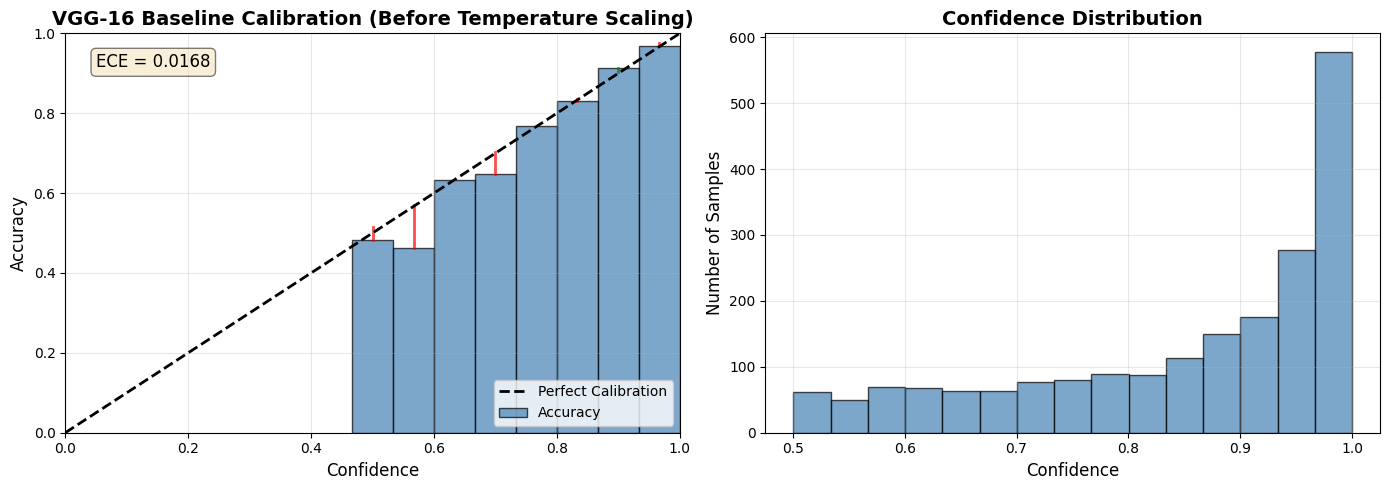


Calibration Statistics by Confidence Bin:
----------------------------------------------------------------------
Bin Range       Count      Accuracy     Confidence   Gap       
----------------------------------------------------------------------
0.47-0.53     60         0.4833       0.5162       0.0329    
0.53-0.60     121        0.4628       0.5702       0.1074    
0.60-0.67     131        0.6336       0.6328       0.0007    
0.67-0.73     139        0.6475       0.7018       0.0543    
0.73-0.80     168        0.7679       0.7675       0.0003    
0.80-0.87     202        0.8317       0.8354       0.0037    
0.87-0.93     324        0.9136       0.9024       0.0112    
0.93-1.00     855        0.9673       0.9749       0.0077    
----------------------------------------------------------------------


In [67]:
# Extract predictions and confidences from test set
vgg.eval()
all_logits_vgg = []
all_labels_vgg = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = vgg(images)
        all_logits_vgg.append(logits.cpu())
        all_labels_vgg.append(labels)

vgg_logits_test = torch.cat(all_logits_vgg).numpy()
vgg_labels_test = torch.cat(all_labels_vgg).numpy()

# Baseline predictions (temperature = 1.0)
vgg_probabilities_baseline = torch.softmax(torch.tensor(vgg_logits_test), dim=1).numpy()
vgg_confidences_baseline = np.max(vgg_probabilities_baseline, axis=1)
vgg_predictions_baseline = np.argmax(vgg_probabilities_baseline, axis=1)

# Calculate metrics
vgg_accuracy_test_baseline = np.mean(vgg_predictions_baseline == vgg_labels_test)

vgg_ece_baseline, vgg_bin_accs_baseline, vgg_bin_confs_baseline, vgg_bin_counts_baseline = calculate_ece(
    vgg_confidences_baseline, vgg_predictions_baseline, vgg_labels_test, n_bins=15
)

# Calculate NLL
vgg_nll_baseline = F.cross_entropy(torch.tensor(vgg_logits_test), torch.tensor(vgg_labels_test, dtype=torch.long), reduction='mean').item()

print(f"VGG-16 Baseline Calibration:")
print(f"  Test Accuracy: {vgg_accuracy_test_baseline*100:.2f}%")
print(f"  ECE: {vgg_ece_baseline:.4f}")
print(f"  NLL: {vgg_nll_baseline:.4f}")
print(f"  Average Confidence: {np.mean(vgg_confidences_baseline):.4f}")
print(f"  Confidence - Accuracy Gap: {np.mean(vgg_confidences_baseline) - vgg_accuracy_test_baseline:.4f}")

# Reliability diagram
ece_plot_vgg = plot_reliability_diagram(
    vgg_confidences_baseline, vgg_predictions_baseline, vgg_labels_test, n_bins=15,
    title="VGG-16 Baseline Calibration (Before Temperature Scaling)"
)

# Bin statistics
print("\nCalibration Statistics by Confidence Bin:")
print("-" * 70)
print(f"{'Bin Range':<15} {'Count':<10} {'Accuracy':<12} {'Confidence':<12} {'Gap':<10}")
print("-" * 70)

bin_boundaries = np.linspace(0, 1, 16)
for i in range(15):
    if vgg_bin_counts_baseline[i] > 0:
        gap = abs(vgg_bin_accs_baseline[i] - vgg_bin_confs_baseline[i])
        print(f"{bin_boundaries[i]:.2f}-{bin_boundaries[i+1]:.2f}     "
              f"{int(vgg_bin_counts_baseline[i]):<10} {vgg_bin_accs_baseline[i]:<12.4f} "
              f"{vgg_bin_confs_baseline[i]:<12.4f} {gap:<10.4f}")

print("-" * 70)

#### 9.3.4 Optimize Temperature Scaling for VGG

Optimal Temperature: 1.00
NLL at optimal T (validation): 0.3304

Calibrated ECE (test set): 0.0168
ECE Reduction: 0.0000 (0.0%)


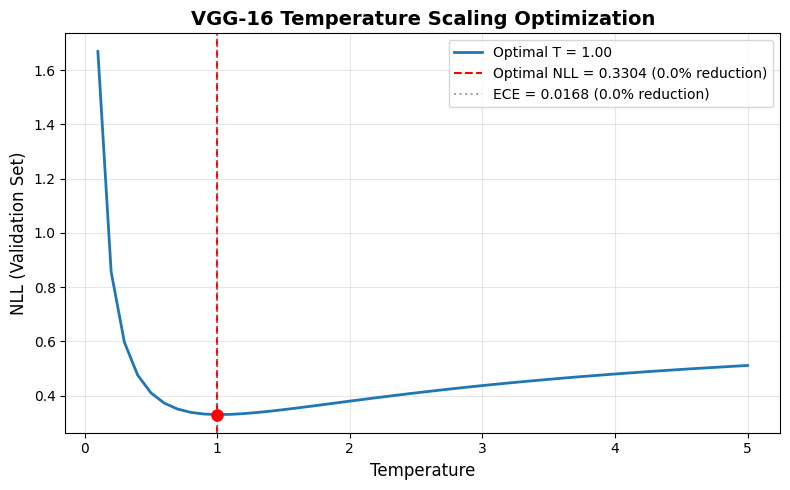

In [69]:
# Get validation set logits
vgg.eval()
all_logits_vgg_val = []
all_labels_vgg_val = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        logits = vgg(images)
        all_logits_vgg_val.append(logits.cpu())
        all_labels_vgg_val.append(labels)

vgg_logits_val = torch.cat(all_logits_vgg_val).numpy()
vgg_labels_val = torch.cat(all_labels_vgg_val).numpy()

# Search for optimal temperature
vgg_temp_range = np.linspace(0.1, 5.0, 50)
vgg_ece_values_temp_sweep = []
vgg_nll_values_temp_sweep = []

for temp in vgg_temp_range:
    scaled_logits = vgg_logits_val / temp
    probs_temp = torch.softmax(torch.tensor(scaled_logits), dim=1).numpy()
    confs_temp = np.max(probs_temp, axis=1)
    preds_temp = np.argmax(probs_temp, axis=1)
    ece_temp, _, _, _ = calculate_ece(confs_temp, preds_temp, vgg_labels_val, n_bins=15)
    nll_temp = F.cross_entropy(torch.tensor(scaled_logits), torch.tensor(vgg_labels_val, dtype=torch.long), reduction='mean').item()
    vgg_ece_values_temp_sweep.append(ece_temp)
    vgg_nll_values_temp_sweep.append(nll_temp)

optimal_idx_vgg = np.argmin(vgg_nll_values_temp_sweep)
vgg_temperature_optimal = vgg_temp_range[optimal_idx_vgg]

baseline_idx_vgg = np.argmin(np.abs(vgg_temp_range - 1.0))
nll_baseline_vgg = vgg_nll_values_temp_sweep[baseline_idx_vgg]
nll_optimal_vgg = vgg_nll_values_temp_sweep[optimal_idx_vgg]
nll_reduction_vgg = (nll_baseline_vgg - nll_optimal_vgg) / nll_baseline_vgg * 100

print(f"Optimal Temperature: {vgg_temperature_optimal:.2f}")
print(f"NLL at optimal T (validation): {vgg_nll_values_temp_sweep[optimal_idx_vgg]:.4f}")

# Apply temperature scaling to test set
vgg_logits_test_scaled = vgg_logits_test / vgg_temperature_optimal
vgg_probabilities_calibrated = torch.softmax(torch.tensor(vgg_logits_test_scaled), dim=1).numpy()
vgg_confidences_calibrated = np.max(vgg_probabilities_calibrated, axis=1)
vgg_predictions_calibrated = np.argmax(vgg_probabilities_calibrated, axis=1)

vgg_ece_calibrated, _, _, _ = calculate_ece(vgg_confidences_calibrated, vgg_predictions_calibrated, vgg_labels_test, n_bins=15)

ece_reduction_vgg = (vgg_ece_baseline - vgg_ece_calibrated) / vgg_ece_baseline * 100

print(f"\nCalibrated ECE (test set): {vgg_ece_calibrated:.4f}")
print(f"ECE Reduction: {(vgg_ece_baseline - vgg_ece_calibrated):.4f} ({100*(vgg_ece_baseline - vgg_ece_calibrated)/vgg_ece_baseline:.1f}%)")

# Temperature search curve
plt.figure(figsize=(8, 5))
plt.plot(vgg_temp_range, vgg_nll_values_temp_sweep, linewidth=2)
plt.axvline(vgg_temperature_optimal, color='red', linestyle='--')
plt.axvline(1.0, color='gray', linestyle=':', alpha=0.7)
plt.plot(vgg_temperature_optimal, vgg_nll_values_temp_sweep[optimal_idx_vgg], 'ro', markersize=8)
plt.xlabel('Temperature', fontsize=12)
plt.ylabel('NLL (Validation Set)', fontsize=12)
plt.title('VGG-16 Temperature Scaling Optimization', fontsize=14, fontweight='bold')
plt.legend([
    f'Optimal T = {vgg_temperature_optimal:.2f}',
    f'Optimal NLL = {vgg_nll_values_temp_sweep[optimal_idx_vgg]:.4f} ({nll_reduction_vgg:.1f}% reduction)',
    f'ECE = {vgg_ece_calibrated:.4f} ({ece_reduction_vgg:.1f}% reduction)'
])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Creating scale analysis comparison...


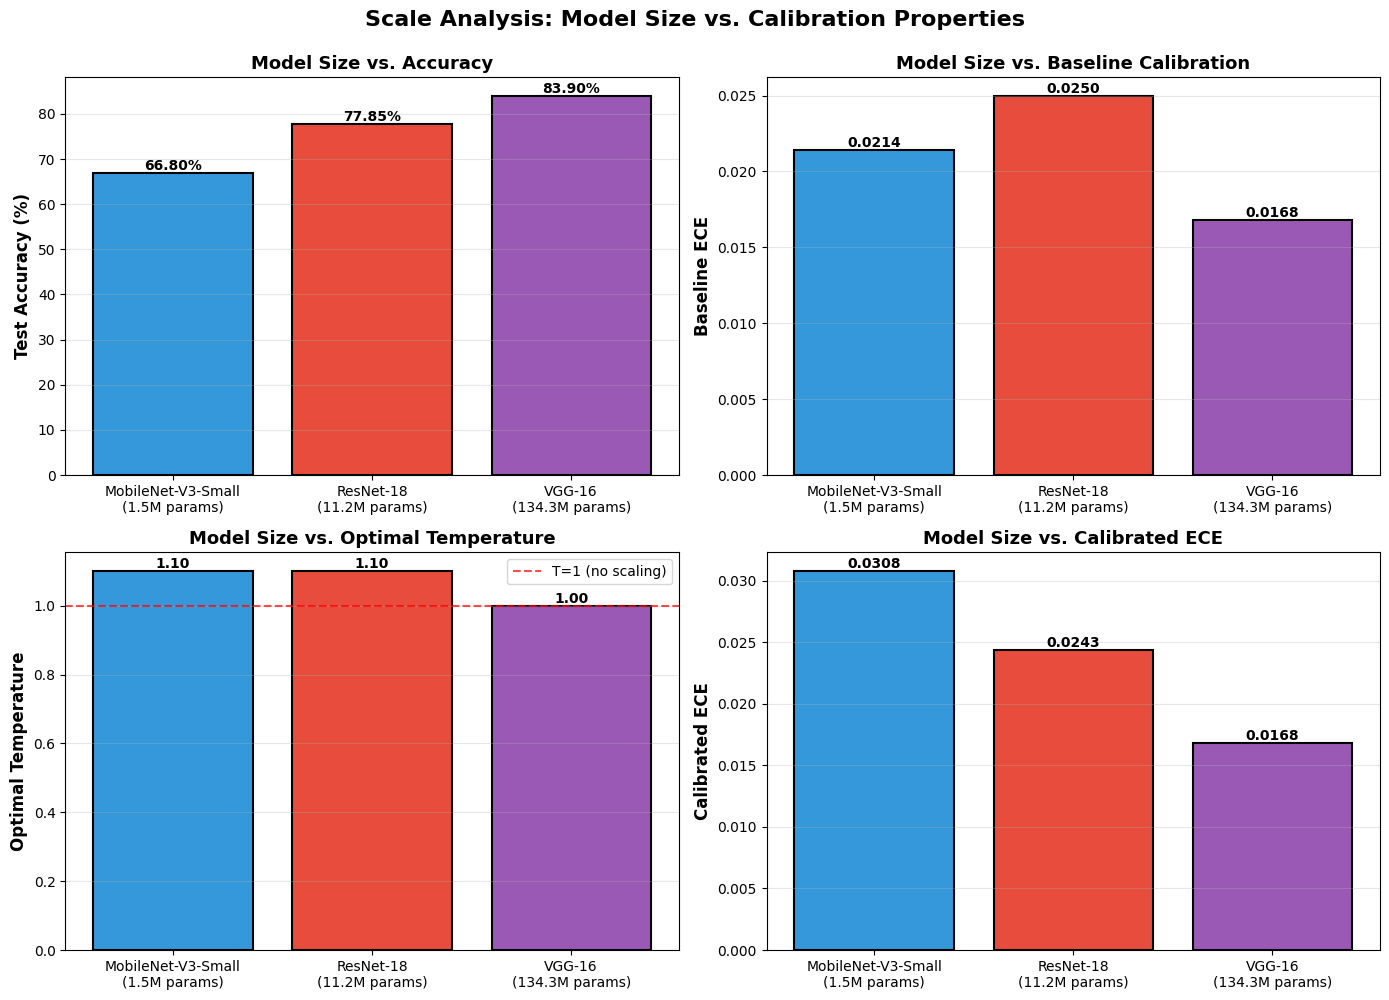


SCALE ANALYSIS SUMMARY
Model                     Params          Accuracy     Base ECE     Opt T      Cal ECE      Reduction   
--------------------------------------------------------------------------------
MobileNet-V3-Small           1.5M        66.80%      0.0214      1.10     0.0308      -43.5%
ResNet-18                   11.2M        77.85%      0.0250      1.10     0.0243        2.4%
VGG-16                     134.3M        83.90%      0.0168      1.00     0.0168        0.0%


In [70]:
# Scale Analysis Comparison Visualization
print("Creating scale analysis comparison...")

# Collect data (you'll need to fill in actual values from training outputs)
# These should be replaced with actual values once models are trained
models_data = {
    'MobileNet-V3-Small': {
        'params': mobilenet_params_total / 1e6,  # Convert to millions
        'trainable': mobilenet_params_trainable,
        'accuracy': mobilenet_accuracy_test,
        'baseline_ece': mobilenet_ece_baseline,
        'optimal_temp': mobilenet_temperature_optimal,
        'calibrated_ece': mobilenet_ece_calibrated
    },
    'ResNet-18': {
        'params': resnet_params_total / 1e6,
        'trainable': resnet_params_trainable,
        'accuracy': resnet_accuracy_test * 100,  # Convert to percentage
        'baseline_ece': resnet_ece_baseline,
        'optimal_temp': resnet_temperature_optimal,
        'calibrated_ece': resnet_ece_calibrated
    },
    'VGG-16': {
        'params': vgg_params_total / 1e6,
        'trainable': vgg_params_trainable,
        'accuracy': vgg_accuracy_test,
        'baseline_ece': vgg_ece_baseline,
        'optimal_temp': vgg_temperature_optimal,
        'calibrated_ece': vgg_ece_calibrated
    }
}

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Scale Analysis: Model Size vs. Calibration Properties', fontsize=16, fontweight='bold', y=0.995)

model_names = list(models_data.keys())
params = [models_data[m]['params'] for m in model_names]
accuracies = [models_data[m]['accuracy'] for m in model_names]
baseline_eces = [models_data[m]['baseline_ece'] for m in model_names]
optimal_temps = [models_data[m]['optimal_temp'] for m in model_names]
calibrated_eces = [models_data[m]['calibrated_ece'] for m in model_names]

colors = ['#3498db', '#e74c3c', '#9b59b6']  # Blue, Red, Purple

# Subplot 1: Parameters vs Accuracy
ax1 = axes[0, 0]
bars1 = ax1.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Model Size vs. Accuracy', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars1, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.2f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add parameter counts on x-axis labels
ax1.set_xticks(range(len(model_names)))
ax1.set_xticklabels([f'{name}\n({params[i]:.1f}M params)' 
                      for i, name in enumerate(model_names)], fontsize=10)

# Subplot 2: Parameters vs Baseline ECE
ax2 = axes[0, 1]
bars2 = ax2.bar(model_names, baseline_eces, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Baseline ECE', fontsize=12, fontweight='bold')
ax2.set_title('Model Size vs. Baseline Calibration', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar, ece in zip(bars2, baseline_eces):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{ece:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels([f'{name}\n({params[i]:.1f}M params)' 
                      for i, name in enumerate(model_names)], fontsize=10)

# Subplot 3: Parameters vs Optimal Temperature
ax3 = axes[1, 0]
bars3 = ax3.bar(model_names, optimal_temps, color=colors, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Optimal Temperature', fontsize=12, fontweight='bold')
ax3.set_title('Model Size vs. Optimal Temperature', fontsize=13, fontweight='bold')
ax3.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='T=1 (no scaling)')
ax3.grid(axis='y', alpha=0.3)
ax3.legend(fontsize=10)
for bar, temp in zip(bars3, optimal_temps):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{temp:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3.set_xticks(range(len(model_names)))
ax3.set_xticklabels([f'{name}\n({params[i]:.1f}M params)' 
                      for i, name in enumerate(model_names)], fontsize=10)

# Subplot 4: Parameters vs Calibrated ECE
ax4 = axes[1, 1]
bars4 = ax4.bar(model_names, calibrated_eces, color=colors, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Calibrated ECE', fontsize=12, fontweight='bold')
ax4.set_title('Model Size vs. Calibrated ECE', fontsize=13, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for bar, ece in zip(bars4, calibrated_eces):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{ece:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax4.set_xticks(range(len(model_names)))
ax4.set_xticklabels([f'{name}\n({params[i]:.1f}M params)' 
                      for i, name in enumerate(model_names)], fontsize=10)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("SCALE ANALYSIS SUMMARY")
print("="*80)
print(f"{'Model':<25} {'Params':<15} {'Accuracy':<12} {'Base ECE':<12} {'Opt T':<10} {'Cal ECE':<12} {'Reduction':<12}")
print("-"*80)
for name in model_names:
    data = models_data[name]
    reduction = 100 * (data['baseline_ece'] - data['calibrated_ece']) / data['baseline_ece']
    print(f"{name:<25} {data['params']:>6.1f}M       {data['accuracy']:>6.2f}%     {data['baseline_ece']:>7.4f}     {data['optimal_temp']:>5.2f}    {data['calibrated_ece']:>7.4f}     {reduction:>6.1f}%")
print("="*80)

## 10. Report Figures and Analysis

This section generates publication-ready figures and analyses for the project report. We compare five models: LeNet-5, Mini-LeNet (trained from scratch), MobileNet-V3-Small, ResNet-18, and VGG-16 (transfer learning).

### 10.1 Prepare Comprehensive Model Data

Collect all necessary data from the four models for report generation.

In [75]:
# Comprehensive data dictionary for all 5 models used in the report
# Includes: LeNet-5, Mini-LeNet (from scratch), MobileNet-V3-Small, ResNet-18, VGG-16 (transfer learning)

report_models = {
    'LeNet-5': {
        # Architecture info
        'params': total_params,
        'params_str': f'{total_params/1000:.1f}K',
        'trainable': total_params,

        # Training performance
        'train_acc': lenet_train_acc,
        'val_acc': lenet_val_acc,
        'test_acc': lenet_accuracy_test * 100,
        'train_val_gap': lenet_train_acc - lenet_val_acc,

        # Training history
        'train_losses': model.loss_during_training,
        'val_losses': model.valid_loss_during_training,
        'train_accs': model.train_acc_during_training,
        'val_accs': model.valid_acc_during_training,

        # Calibration - Baseline
        'confidences_baseline': lenet_confidences_baseline,
        'predictions_baseline': lenet_predictions_baseline,
        'ece_baseline': lenet_ece_baseline,
        'avg_conf_baseline': np.mean(lenet_confidences_baseline),

        # Calibration - After temperature scaling
        'optimal_temp': lenet_temperature_optimal,
        'confidences_calibrated': lenet_confidences_calibrated,
        'predictions_calibrated': lenet_predictions_calibrated,
        'ece_calibrated': lenet_ece_calibrated,
        'avg_conf_calibrated': np.mean(lenet_confidences_calibrated),
        'ece_reduction': ((lenet_ece_baseline - lenet_ece_calibrated) / lenet_ece_baseline) * 100,

        # Temperature scaling data
        'temp_range': lenet_temp_range,
        'ece_values_temp_sweep': lenet_ece_values,
        'nll_values_temp_sweep': lenet_nll_values,

        # Labels
        'labels': lenet_labels_test,

        'logits_test': lenet_logits,

        # Visual properties
        'color': '#FF8C00',  # Orange
        'type': 'From Scratch'
    },

    'Mini-LeNet': {
        # Architecture info
        'params': mini_total_params,
        'params_str': f'{mini_total_params/1000:.1f}K',
        'trainable': mini_total_params,

        # Training performance
        'train_acc': mini_train_accs[-1],
        'val_acc': mini_val_accs[-1],
        'test_acc': mini_accuracy_test * 100,
        'train_val_gap': mini_train_accs[-1] - mini_val_accs[-1],

        # Training history
        'train_losses': mini_train_losses,
        'val_losses': mini_val_losses,
        'train_accs': mini_train_accs,
        'val_accs': mini_val_accs,

        # Calibration - Baseline
        'confidences_baseline': mini_confidences_baseline,
        'predictions_baseline': mini_predictions_baseline,
        'ece_baseline': mini_ece_baseline,
        'avg_conf_baseline': np.mean(mini_confidences_baseline),

        # Calibration - After temperature scaling
        'optimal_temp': mini_temperature_optimal,
        'confidences_calibrated': mini_confidences_calibrated,
        'predictions_calibrated': mini_predictions_calibrated,
        'ece_calibrated': mini_ece_calibrated,
        'avg_conf_calibrated': np.mean(mini_confidences_calibrated),
        'ece_reduction': ((mini_ece_baseline - mini_ece_calibrated) / mini_ece_baseline) * 100,

        # Temperature scaling data
        'temp_range': mini_temp_range,
        'ece_values_temp_sweep': mini_ece_values,
        'nll_values_temp_sweep': mini_nll_values,

        # Labels
        'labels': mini_labels_test,

        # Visual properties
        'color': '#2E8B57',  # Sea Green
        'type': 'From Scratch'
    },

    'MobileNet-V3': {
        # Architecture info
        'params': mobilenet_params_total,
        'params_str': f'{mobilenet_params_total/1e6:.1f}M',
        'trainable': mobilenet_params_trainable,

        # Training performance
        'train_acc': mobilenet_acc_train[-1],
        'val_acc': mobilenet_acc_val[-1],
        'test_acc': mobilenet_accuracy_test,  # Already in percentage
        'train_val_gap': mobilenet_acc_train[-1] - mobilenet_acc_val[-1],

        # Training history
        'train_losses': mobilenet_loss_train,
        'val_losses': mobilenet_loss_val,
        'train_accs': mobilenet_acc_train,
        'val_accs': mobilenet_acc_val,

        # Calibration - Baseline
        'confidences_baseline': mobilenet_confidences_baseline,
        'predictions_baseline': mobilenet_predictions_baseline,
        'ece_baseline': mobilenet_ece_baseline,
        'avg_conf_baseline': np.mean(mobilenet_confidences_baseline),

        # Calibration - After temperature scaling
        'optimal_temp': mobilenet_temperature_optimal,
        'confidences_calibrated': mobilenet_confidences_calibrated,
        'predictions_calibrated': mobilenet_predictions_calibrated,
        'ece_calibrated': mobilenet_ece_calibrated,
        'avg_conf_calibrated': np.mean(mobilenet_confidences_calibrated),
        'ece_reduction': ((mobilenet_ece_baseline - mobilenet_ece_calibrated) / mobilenet_ece_baseline) * 100,

        # Temperature scaling data
        'temp_range': mobilenet_temp_range,
        'ece_values_temp_sweep': mobilenet_ece_values_temp_sweep,
        'nll_values_temp_sweep': mobilenet_nll_values_temp_sweep,

        # Labels
        'labels': mobilenet_labels_test,

        # Visual properties
        'color': '#3498db',  # Blue
        'type': 'Transfer Learning'
    },

    'ResNet-18': {
        # Architecture info
        'params': resnet_params_total,
        'params_str': f'{resnet_params_total/1e6:.1f}M',
        'trainable': resnet_params_trainable,

        # Training performance
        'train_acc': resnet_acc_train[-1],
        'val_acc': resnet_acc_val[-1],
        'test_acc': resnet_accuracy_test * 100,
        'train_val_gap': resnet_acc_train[-1] - resnet_acc_val[-1],

        # Training history
        'train_losses': resnet_loss_train,
        'val_losses': resnet_loss_val,
        'train_accs': resnet_acc_train,
        'val_accs': resnet_acc_val,

        # Calibration - Baseline
        'confidences_baseline': resnet_confidences_baseline,
        'predictions_baseline': resnet_predictions_baseline,
        'ece_baseline': resnet_ece_baseline,
        'avg_conf_baseline': np.mean(resnet_confidences_baseline),

        # Calibration - After temperature scaling
        'optimal_temp': resnet_temperature_optimal,
        'confidences_calibrated': resnet_confidences_calibrated,
        'predictions_calibrated': resnet_predictions_calibrated,
        'ece_calibrated': resnet_ece_calibrated,
        'avg_conf_calibrated': np.mean(resnet_confidences_calibrated),
        'ece_reduction': ((resnet_ece_baseline - resnet_ece_calibrated) / resnet_ece_baseline) * 100,

        # Temperature scaling data
        'temp_range': resnet_temp_range,
        'ece_values_temp_sweep': resnet_ece_values_temp_sweep,
        'nll_values_temp_sweep': resnet_nll_values_temp_sweep,

        # Labels
        'labels': resnet_labels_test,

        # Visual properties
        'color': '#e74c3c',  # Red
        'type': 'Transfer Learning'
    },

    'VGG-16': {
        # Architecture info
        'params': vgg_params_total,
        'params_str': f'{vgg_params_total/1e6:.1f}M',
        'trainable': vgg_params_trainable,

        # Training performance
        'train_acc': vgg_acc_train[-1],
        'val_acc': vgg_acc_val[-1],
        'test_acc': vgg_accuracy_test,
        'train_val_gap': vgg_acc_train[-1] - vgg_acc_val[-1],

        # Training history
        'train_losses': None,  # Not tracked for VGG
        'val_losses': None,    # Not tracked for VGG
        'train_accs': vgg_acc_train,
        'val_accs': vgg_acc_val,

        # Calibration - Baseline
        'confidences_baseline': vgg_confidences_baseline,
        'predictions_baseline': vgg_predictions_baseline,
        'ece_baseline': vgg_ece_baseline,
        'avg_conf_baseline': np.mean(vgg_confidences_baseline),

        # Calibration - After temperature scaling
        'optimal_temp': vgg_temperature_optimal,
        'confidences_calibrated': vgg_confidences_calibrated,
        'predictions_calibrated': vgg_predictions_calibrated,
        'ece_calibrated': vgg_ece_calibrated,
        'avg_conf_calibrated': np.mean(vgg_confidences_calibrated),
        'ece_reduction': ((vgg_ece_baseline - vgg_ece_calibrated) / vgg_ece_baseline) * 100,

        # Temperature scaling data
        'temp_range': vgg_temp_range,
        'ece_values_temp_sweep': vgg_ece_values_temp_sweep,
        'nll_values_temp_sweep': None,

        # Labels
        'labels': vgg_labels_test,

        # Visual properties
        'color': '#9b59b6',  # Purple
        'type': 'Transfer Learning'
    }
}

# Verification: Data loaded successfully
print(f"✓ Report data prepared for {len(report_models)} models")

✓ Report data prepared for 5 models


### 10.2 Table 1: Model Training Performance Summary

This table shows the training performance of all models, focusing on:
- Model architecture and parameter counts (total and trainable)
- Training accuracy, validation accuracy, and test accuracy
- Train-validation gap (overfitting indicator)

This will be the first result in the Results section of the report.

In [94]:
# Print Table 1: Model Training Performance Summary in clean format
print("Table 1: Model Training Performance Summary")
print("=" * 80)
header = ("{:<15} {:<10} {:<12} {:<10} {:<10} {:<8} {:<8} {:<10} {:<12}")
print(header.format('Model', 'Type', 'Total Params', 'Trainable', 'Train Acc', 'Val Acc', 'Gap', 'Test Acc', 'Conf Gap (%)'))
print("-" * 80)

for name, data in report_models.items():
    model_type = "Scratch" if data['type'] == 'From Scratch' else "Transfer"
    trainable_str = data['params_str'] if data['params'] == data['trainable'] else f"{data['trainable']:,}"
    conf_gap = (data.get('avg_conf_baseline', 0) - (data.get('test_acc', 0)/100)) * 100
    row = ("{:<15} {:<10} {:<12} {:<10} {:<10.1f} {:<8.1f} {:<8.1f} {:<10.1f} {:<12.1f}")
    print(row.format(name, model_type, data['params_str'], trainable_str, data['train_acc'], data['val_acc'], data['train_val_gap'], data['test_acc'], conf_gap))
print("=" * 80)

Table 1: Model Training Performance Summary
Model           Type       Total Params Trainable  Train Acc  Val Acc  Gap      Test Acc   Conf Gap (%)
--------------------------------------------------------------------------------
LeNet-5         Scratch    61.3K        61.3K      96.8       79.1     17.7     77.0       16.1        
Mini-LeNet      Scratch    4.0K         4.0K       79.5       75.2     4.3      77.5       1.5         
MobileNet-V3    Transfer   1.5M         2,050      68.0       67.5     0.5      66.8       -0.3        
ResNet-18       Transfer   11.2M        1,026      79.4       78.7     0.8      77.8       1.0         
VGG-16          Transfer   134.3M       8,194      86.7       85.8     0.9      83.9       1.3         


### 10.3 Figure 2: Temperature Scaling Curves (ECE and NLL vs T)

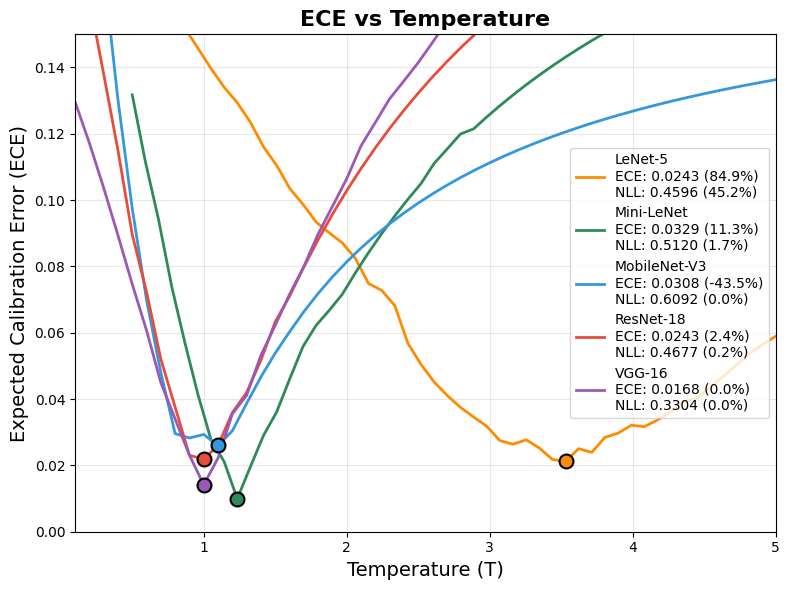

Saved ECE figure as temp_scaling_ece.png and temp_scaling_ece.pdf (PGF attempted).


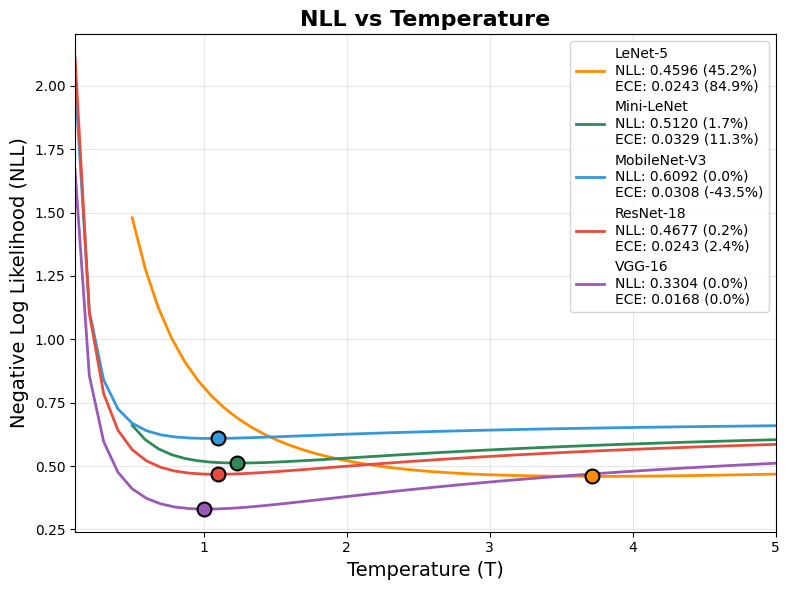

Saved NLL figure as temp_scaling_nll.png and temp_scaling_nll.pdf (PGF attempted).


In [78]:
# Figure: Temperature Scaling - separate ECE and NLL plots
import matplotlib.pyplot as plt
import matplotlib

# Update report_models with NLL data for all models
report_models['ResNet-18']['nll_values_temp_sweep'] = resnet_nll_values_temp_sweep
report_models['VGG-16']['nll_values_temp_sweep'] = vgg_nll_values_temp_sweep

# Calculate NLL reductions for all models
for model_name, data in report_models.items():
    if 'nll_values_temp_sweep' in data and data['nll_values_temp_sweep'] is not None:
        baseline_idx = np.argmin(np.abs(data['temp_range'] - 1.0))
        nll_baseline = data['nll_values_temp_sweep'][baseline_idx]
        optimal_idx = np.argmin(data['nll_values_temp_sweep'])
        nll_optimal = data['nll_values_temp_sweep'][optimal_idx]
        nll_reduction = (nll_baseline - nll_optimal) / nll_baseline * 100
        data['nll_reduction'] = nll_reduction
        data['nll_optimal'] = nll_optimal

# --- ECE plot (saved for report) ---
fig_ece, ax = plt.subplots(figsize=(8, 6))
for model_name, data in report_models.items():
    ax.plot(data['temp_range'], data['ece_values_temp_sweep'], color=data['color'], linewidth=2, label=f'{model_name}\nECE: {data["ece_calibrated"]:.4f} ({data["ece_reduction"]:.1f}%)\nNLL: {data["nll_optimal"]:.4f} ({data["nll_reduction"]:.1f}%)')
    # Mark optimal T (ensure dot is on the line)
    optimal_idx = np.argmin(data['ece_values_temp_sweep'])
    ax.scatter(data['temp_range'][optimal_idx], data['ece_values_temp_sweep'][optimal_idx], color=data['color'], s=100, marker='o', edgecolors='black', linewidth=1.5, zorder=5)

ax.set_xlabel('Temperature (T)', fontsize=14)
ax.set_ylabel('Expected Calibration Error (ECE)', fontsize=14)
ax.set_title('ECE vs Temperature', fontsize=16, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.1, 5.0)
ax.set_ylim(0, 0.15)
plt.tight_layout()
# Save in multiple formats: high-DPI PNG, PDF (vector), and try PGF (for LaTeX integration)
fig_ece.savefig('temp_scaling_ece.png', dpi=600, bbox_inches='tight')
fig_ece.savefig('temp_scaling_ece.pdf', bbox_inches='tight')
try:
    # PGF export: matplotlib must be configured for PGF backend; attempt and ignore errors
    fig_ece.savefig('temp_scaling_ece.pgf', bbox_inches='tight')
except Exception as e:
    print('PGF export not available:', e)
plt.show()

print('Saved ECE figure as temp_scaling_ece.png and temp_scaling_ece.pdf (PGF attempted).')

# --- NLL plot (saved for report) ---
fig_nll, ax2 = plt.subplots(figsize=(8, 6))
for model_name, data in report_models.items():
    if 'nll_values_temp_sweep' in data and data['nll_values_temp_sweep'] is not None:
        ax2.plot(data['temp_range'], data['nll_values_temp_sweep'], color=data['color'], linewidth=2, label=f'{model_name}\nNLL: {data["nll_optimal"]:.4f} ({data["nll_reduction"]:.1f}%)\nECE: {data["ece_calibrated"]:.4f} ({data["ece_reduction"]:.1f}%)')
        optimal_idx = np.argmin(data['nll_values_temp_sweep'])
        ax2.scatter(data['temp_range'][optimal_idx], data['nll_values_temp_sweep'][optimal_idx], color=data['color'], s=100, marker='o', edgecolors='black', linewidth=1.5, zorder=5)

ax2.set_xlabel('Temperature (T)', fontsize=14)
ax2.set_ylabel('Negative Log Likelihood (NLL)', fontsize=14)
ax2.set_title('NLL vs Temperature', fontsize=16, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.1, 5.0)
plt.tight_layout()
# Save in multiple formats: high-DPI PNG, PDF (vector), and try PGF (for LaTeX integration)
fig_nll.savefig('temp_scaling_nll.png', dpi=600, bbox_inches='tight')
fig_nll.savefig('temp_scaling_nll.pdf', bbox_inches='tight')
try:
    # PGF export: matplotlib must be configured for PGF backend; attempt and ignore errors
    fig_nll.savefig('temp_scaling_nll.pgf', bbox_inches='tight')
except Exception as e:
    print('PGF export not available:', e)
plt.show()

print('Saved NLL figure as temp_scaling_nll.png and temp_scaling_nll.pdf (PGF attempted).')

### 10.4 Figure 3: Reliability Diagrams for All Models

This figure shows the reliability diagrams for all trained models before and after temperature scaling calibration. The top row displays diagrams before scaling, and the bottom row shows the improved calibration after applying optimal temperature scaling. Each column represents a different model.

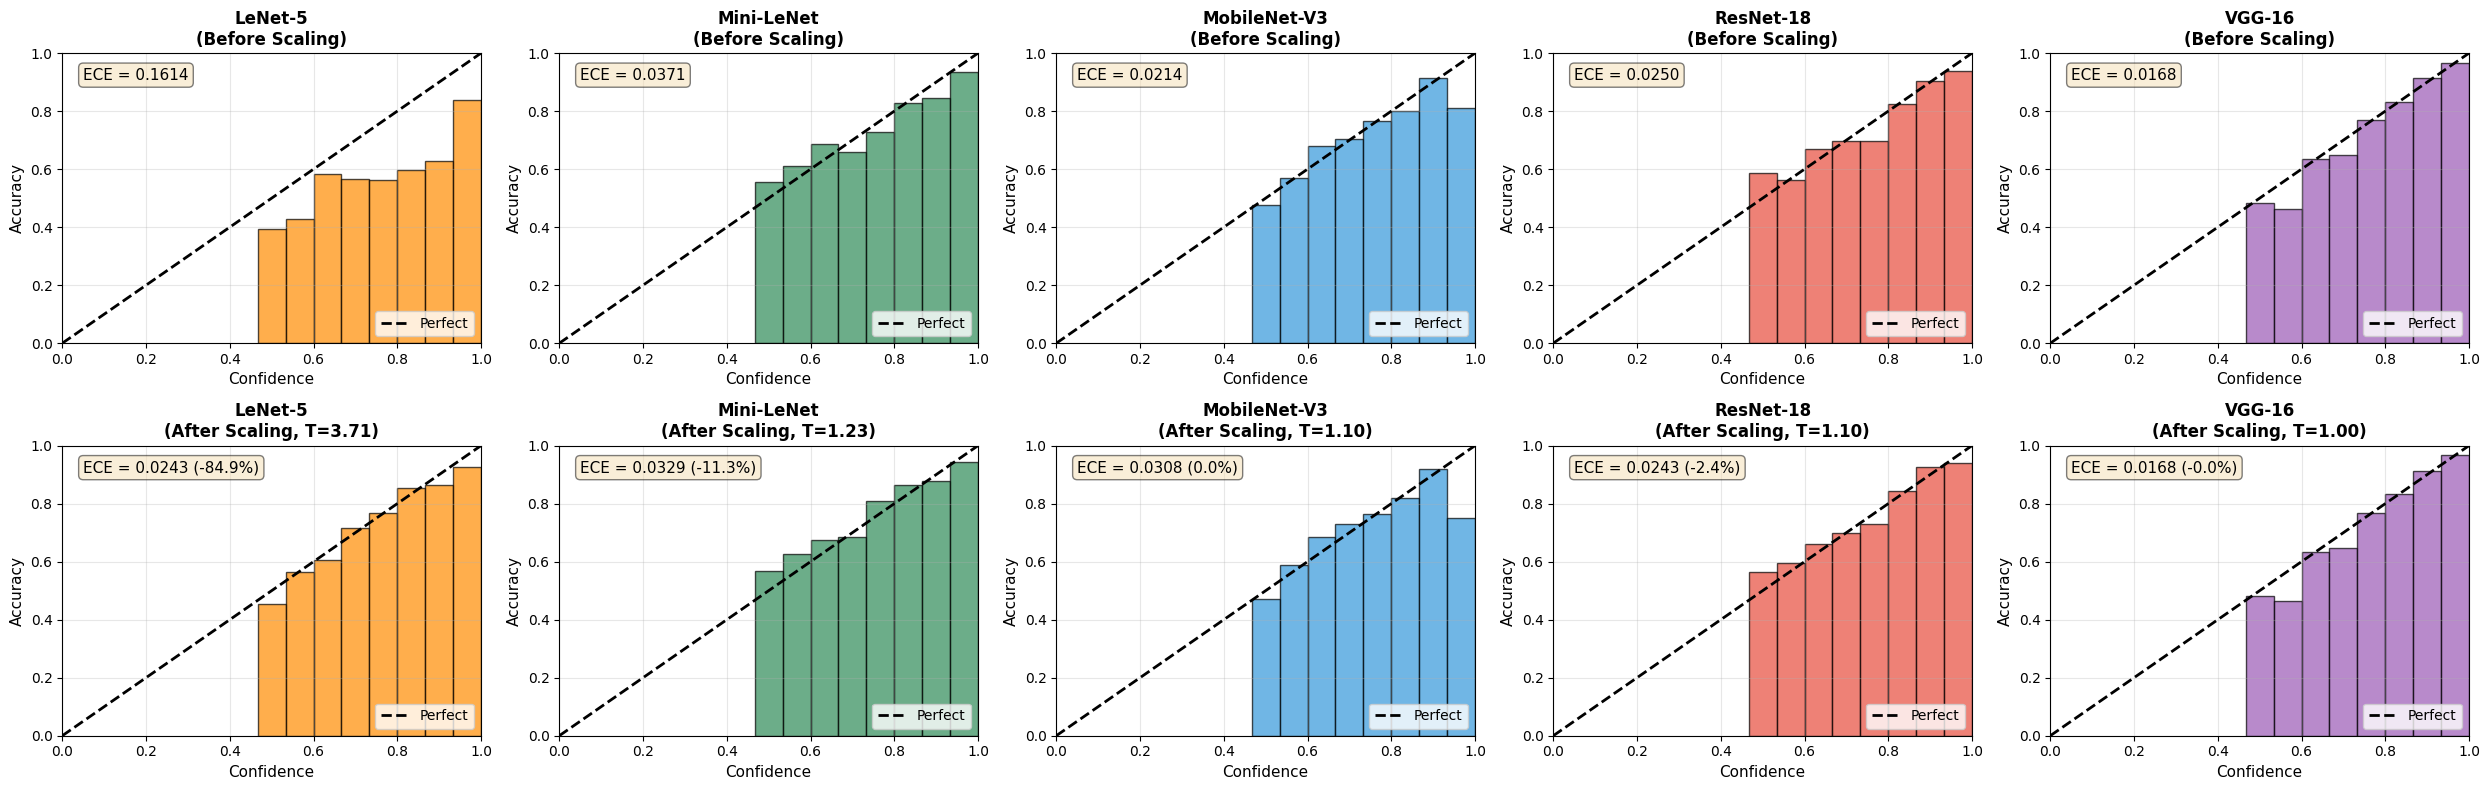

Saved reliability diagrams figure as reliability_diagrams.png and reliability_diagrams.pdf (PGF attempted).


In [88]:
# Figure 3: Reliability Diagrams for All Models (Before and After Temperature Scaling)
import matplotlib.pyplot as plt
import numpy as np

n_models = len(report_models)
fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 8))
if n_models == 1:
    axes = axes.reshape(2, -1)

model_names = list(report_models.keys())

for col, model_name in enumerate(model_names):
    data = report_models[model_name]
    color = data['color']
    
    # Before scaling (row 0)
    ax_before = axes[0, col]
    confidences_before = data['confidences_baseline']
    predictions_before = data['predictions_baseline']
    labels = data['labels']
    ece_before = data['ece_baseline']
    
    ece_calc_before, bin_accs_before, bin_confs_before, bin_counts_before = calculate_ece(confidences_before, predictions_before, labels, n_bins=15)
    non_empty_before = bin_counts_before > 0
    bin_centers = np.linspace(0, 1, 16)[:-1] + 0.5/15
    widths = 1.0 / 15
    
    ax_before.bar(bin_centers[non_empty_before], bin_accs_before[non_empty_before], width=widths, 
           edgecolor='black', alpha=0.7, color=color)
    ax_before.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect')
    ax_before.text(0.05, 0.95, f'ECE = {ece_before:.4f}', transform=ax_before.transAxes, fontsize=11, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax_before.set_xlabel('Confidence', fontsize=11)
    ax_before.set_ylabel('Accuracy', fontsize=11)
    ax_before.set_title(f'{model_name}\n(Before Scaling)', fontsize=12, fontweight='bold')
    ax_before.legend(loc='lower right')
    ax_before.grid(alpha=0.3)
    ax_before.set_xlim([0, 1])
    ax_before.set_ylim([0, 1])
    
    # After scaling (row 1)
    ax_after = axes[1, col]
    confidences_after = data['confidences_calibrated']
    predictions_after = data['predictions_calibrated']
    ece_after = data['ece_calibrated']
    
    ece_calc_after, bin_accs_after, bin_confs_after, bin_counts_after = calculate_ece(confidences_after, predictions_after, labels, n_bins=15)
    non_empty_after = bin_counts_after > 0
    
    ax_after.bar(bin_centers[non_empty_after], bin_accs_after[non_empty_after], width=widths, 
           edgecolor='black', alpha=0.7, color=color)
    ax_after.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect')
    reduction_text = f'{-data["ece_reduction"]:.1f}%' if data["ece_reduction"] > 0 else '0.0%'
    ax_after.text(0.05, 0.95, f'ECE = {ece_after:.4f} ({reduction_text})', transform=ax_after.transAxes, fontsize=11, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax_after.set_xlabel('Confidence', fontsize=11)
    ax_after.set_ylabel('Accuracy', fontsize=11)
    ax_after.set_title(f'{model_name}\n(After Scaling, T={data["optimal_temp"]:.2f})', fontsize=12, fontweight='bold')
    ax_after.legend(loc='lower right')
    ax_after.grid(alpha=0.3)
    ax_after.set_xlim([0, 1])
    ax_after.set_ylim([0, 1])

plt.tight_layout()
# Save in multiple formats: high-DPI PNG, PDF (vector), and try PGF (for LaTeX integration)
fig.savefig('reliability_diagrams.png', dpi=600, bbox_inches='tight')
fig.savefig('reliability_diagrams.pdf', bbox_inches='tight')
try:
    # PGF export: matplotlib must be configured for PGF backend; attempt and ignore errors
    fig.savefig('reliability_diagrams.pgf', bbox_inches='tight')
except Exception as e:
    print('PGF export not available:', e)
plt.show()

print('Saved reliability diagrams figure as reliability_diagrams.png and reliability_diagrams.pdf (PGF attempted).')